# Model Team B – XGBoost Ensemble Baseline + Extensions

This notebook implements the **Model Team B** workflow for recession forecasting using the **pre-1986 extended quarterly dataset** (1948 Q1 – 2026 Q1):

1. XGBoost classifiers for **1Q, 2Q, 3Q ahead**
2. Feature engineering with **lags, rolling averages, and regime dummies** (identical to Team A)
3. **SHAP-based feature importance** ranking (replaces mutual information)
4. **Hyperparameter tuning** via time-series-aware cross-validation
5. **Walk-forward evaluation** (expanding window)
6. **Elastic Net Logistic Regression** (penalised linear benchmark)
7. **SMOTE + XGBoost** (minority-class oversampling inside folds)
8. **Stacking Ensemble** (L2 logistic meta-learner)
9. **Robustness checks** across macroeconomic regimes
10. **LSTM feasibility evaluation** (sequence model comparison)

> **Dataset change:** This version uses `master_dataset_before_1986.csv`, which contains **raw macroeconomic indicators** (UNRATE, INDPRO, CPIAUCSL, FEDFUNDS) rather than pre-transformed columns. Transformations (first differences, log year-over-year growth) are computed in this notebook.


# 1 – Load Libraries & Environment Setup

In [13]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import statsmodels.api as sm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
shap.initjs()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Libraries loaded. PyTorch device: {DEVICE}")
print("Extra requirements: pip install imbalanced-learn torch")

Libraries loaded. PyTorch device: cpu
Extra requirements: pip install imbalanced-learn torch


# 2 – Data Ingestion & Preprocessing

## 2.1 – Load the Data

In [14]:
# Updated to use the pre-1986 extended dataset
DATA_PATH = "DS_SOURCES_PIPELINE/master_dataset_before_1986.csv"
OUTDIR = "model_team_b_outputs"
os.makedirs(OUTDIR, exist_ok=True)
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()


Dataset shape: (313, 15)
Date range: 1948-01-01 00:00:00 to 2026-01-01 00:00:00


,Date,USRECD,T10Y2Y,UNRATE,INDPRO,CPIAUCSL,TEDRATE,BAA10Y,FEDFUNDS,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,BAA10Y_missing,T10Y2Y_missing,FEDFUNDS_missing
0,1948-01-01,0.0,0.788355,3.733333,14.316467,23.616667,NaN,2.126885,4.326667,0.0,0.0,1.0,1,1,1
1,1948-04-01,0.0,0.788355,3.666667,14.469067,23.993333,NaN,2.126885,4.326667,0.0,1.0,1.0,1,1,1
2,1948-07-01,0.0,0.788355,3.766667,14.603667,24.396667,NaN,2.126885,4.326667,1.0,1.0,1.0,1,1,1
3,1948-10-01,1.0,0.788355,3.833333,14.451133,24.173333,NaN,2.126885,4.326667,1.0,1.0,1.0,1,1,1
4,1949-01-01,1.0,0.788355,4.666667,13.984367,23.943333,NaN,2.126885,4.326667,1.0,1.0,1.0,1,1,1


## 2.2 – Data Cleaning

In [15]:
df = df.drop(columns=["BAA10Y_missing", "T10Y2Y_missing", "FEDFUNDS_missing", "TEDRATE"])
print(f"Cleaned shape: {df.shape}")
df.head()


Cleaned shape: (313, 11)


,Date,USRECD,T10Y2Y,UNRATE,INDPRO,CPIAUCSL,BAA10Y,FEDFUNDS,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead
0,1948-01-01,0.0,0.788355,3.733333,14.316467,23.616667,2.126885,4.326667,0.0,0.0,1.0
1,1948-04-01,0.0,0.788355,3.666667,14.469067,23.993333,2.126885,4.326667,0.0,1.0,1.0
2,1948-07-01,0.0,0.788355,3.766667,14.603667,24.396667,2.126885,4.326667,1.0,1.0,1.0
3,1948-10-01,1.0,0.788355,3.833333,14.451133,24.173333,2.126885,4.326667,1.0,1.0,1.0
4,1949-01-01,1.0,0.788355,4.666667,13.984367,23.943333,2.126885,4.326667,1.0,1.0,1.0


## 2.3 – Feature Engineering

In [16]:
# The pre-1986 dataset provides raw macroeconomic indicators.
# Compute the same transformations used in the after-1986 (pre-transformed) dataset:
#   UNRATE_d1       = first difference of unemployment rate
#   INDPRO_lgyoy    = log year-over-year growth of industrial production
#   CPIAUCSL_lgyoy  = log year-over-year growth of CPI
#   FEDFUNDS_d1     = first difference of federal funds rate

df["UNRATE_d1"]      = df["UNRATE"].diff()
df["INDPRO_lgyoy"]   = np.log(df["INDPRO"] / df["INDPRO"].shift(4))   # 4-quarter (YoY) log growth
df["CPIAUCSL_lgyoy"] = np.log(df["CPIAUCSL"] / df["CPIAUCSL"].shift(4))
df["FEDFUNDS_d1"]    = df["FEDFUNDS"].diff()

signal_cols = [
    "T10Y2Y", "BAA10Y",
    "UNRATE_d1", "INDPRO_lgyoy", "CPIAUCSL_lgyoy", "FEDFUNDS_d1"
]
edf = df.copy()
for col in signal_cols:
    for lag in [1, 2, 3]:
        edf[f"{col}_lag{lag}"] = edf[col].shift(lag)
    for win in [3, 6]:
        edf[f"{col}_roll{win}"] = edf[col].rolling(win, min_periods=win).mean()
edf["post_2008"] = (edf["Date"] >= pd.Timestamp("2008-01-01")).astype(int)
edf["post_2020"] = (edf["Date"] >= pd.Timestamp("2020-01-01")).astype(int)
target_cols = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]
# Exclude raw macro columns that were only used to derive the transformed ones
raw_macro_cols = ["UNRATE", "INDPRO", "CPIAUCSL", "FEDFUNDS"]
feature_cols = [c for c in edf.columns if c not in ["Date", "USRECD"] + target_cols + raw_macro_cols]
print(f"Rows: {len(edf)}, Engineered features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")


Rows: 313, Engineered features: 38
Feature columns: ['T10Y2Y', 'BAA10Y', 'UNRATE_d1', 'INDPRO_lgyoy', 'CPIAUCSL_lgyoy', 'FEDFUNDS_d1', 'T10Y2Y_lag1', 'T10Y2Y_lag2', 'T10Y2Y_lag3', 'T10Y2Y_roll3', 'T10Y2Y_roll6', 'BAA10Y_lag1', 'BAA10Y_lag2', 'BAA10Y_lag3', 'BAA10Y_roll3', 'BAA10Y_roll6', 'UNRATE_d1_lag1', 'UNRATE_d1_lag2', 'UNRATE_d1_lag3', 'UNRATE_d1_roll3', 'UNRATE_d1_roll6', 'INDPRO_lgyoy_lag1', 'INDPRO_lgyoy_lag2', 'INDPRO_lgyoy_lag3', 'INDPRO_lgyoy_roll3', 'INDPRO_lgyoy_roll6', 'CPIAUCSL_lgyoy_lag1', 'CPIAUCSL_lgyoy_lag2', 'CPIAUCSL_lgyoy_lag3', 'CPIAUCSL_lgyoy_roll3', 'CPIAUCSL_lgyoy_roll6', 'FEDFUNDS_d1_lag1', 'FEDFUNDS_d1_lag2', 'FEDFUNDS_d1_lag3', 'FEDFUNDS_d1_roll3', 'FEDFUNDS_d1_roll6', 'post_2008', 'post_2020']


# 3 – Shared Utilities

In [17]:
horizons = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]

def prep_dataset(horizon):
    data = edf.dropna(subset=feature_cols + [horizon]).copy().reset_index(drop=True)
    return data, data[feature_cols], data[horizon].astype(int)

def expanding_splits(n, initial=60, test=8, step=8):
    splits, start = [], initial
    while start + test <= n:
        splits.append((np.arange(start), np.arange(start, start + test)))
        start += step
    return splits

def record_metrics(store, horizon, model_name, ys, preds):
    store.append({
        "horizon":           horizon.replace("Target_", "").replace("_ahead", ""),
        "model":             model_name,
        "oof_n":             len(ys),
        "positives":         int(ys.sum()),
        "auc":               roc_auc_score(ys, preds),
        "average_precision": average_precision_score(ys, preds),
        "brier":             brier_score_loss(ys, preds),
        "log_loss":          log_loss(ys, preds, labels=[0, 1]),
    })

all_results = []
oof_store   = {}
shap_store  = {}
best_params_store = {}
print("Utilities defined.")

Utilities defined.


# 4 – XGBoost Models

## 4.1 – Hyperparameter Grid & Inner CV

In [18]:
PARAM_GRID = list(ParameterGrid({
    "n_estimators": [200, 400], "max_depth": [2, 3],
    "learning_rate": [0.05, 0.10], "subsample": [0.8],
    "colsample_bytree": [0.8], "reg_alpha": [0.1, 1.0], "reg_lambda": [1.0, 5.0],
}))
print(f"Hyperparameter combinations: {len(PARAM_GRID)}")

def inner_cv_best_params(Xtr, ytr, param_grid, n_splits=3):
    n = len(Xtr)
    inner_initial = max(20, n // (n_splits + 1))
    inner_test    = max(5, (n - inner_initial) // n_splits)
    best_score, best_params = -np.inf, param_grid[0]
    for params in param_grid:
        scores, start = [], inner_initial
        while start + inner_test <= n:
            itr = np.arange(start); ite = np.arange(start, start + inner_test); start += inner_test
            if len(np.unique(ytr[itr])) < 2 or len(np.unique(ytr[ite])) < 2: continue
            spw = (ytr[itr] == 0).sum() / max((ytr[itr] == 1).sum(), 1)
            clf = XGBClassifier(**params, scale_pos_weight=spw, use_label_encoder=False,
                                eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
            clf.fit(Xtr[itr], ytr[itr])
            scores.append(roc_auc_score(ytr[ite], clf.predict_proba(Xtr[ite])[:, 1]))
        if scores and np.mean(scores) > best_score:
            best_score, best_params = np.mean(scores), params
    return best_params

Hyperparameter combinations: 32


## 4.2 – Walk-Forward Validation

In [19]:
for horizon in horizons:
    print(f"\n{'='*55}\nXGBoost — {horizon}\n{'='*55}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    for model_name, tune in [("xgb_tuned", True), ("xgb_default", False)]:
        preds, ys, dates, shap_vals_list, shap_X_list, fold_params = [], [], [], [], [], []
        for tr, te in splits:
            Xtr_raw, Xte_raw = X_np[tr], X_np[te]
            ytr, yte = y_np[tr], y_np[te]
            imp = SimpleImputer(strategy="median")
            Xtr_imp = imp.fit_transform(Xtr_raw); Xte_imp = imp.transform(Xte_raw)
            spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
            params = (inner_cv_best_params(Xtr_imp, ytr, PARAM_GRID) if tune
                      else {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05,
                            "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 2.0})
            fold_params.append(params)
            clf = XGBClassifier(**params, scale_pos_weight=spw, use_label_encoder=False,
                                eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
            clf.fit(Xtr_imp, ytr)
            p = clf.predict_proba(Xte_imp)[:, 1]
            preds.extend(p); ys.extend(yte.tolist()); dates.extend(data.iloc[te]["Date"].tolist())
            explainer = shap.TreeExplainer(clf)
            sv = explainer.shap_values(Xte_imp)
            if isinstance(sv, list): sv = sv[1]
            shap_vals_list.append(sv); shap_X_list.append(Xte_imp)
        ys, preds = np.array(ys), np.array(preds)
        record_metrics(all_results, horizon, model_name, ys, preds)
        oof_store[(horizon, model_name)] = pd.DataFrame(
            {"Date": pd.to_datetime(dates), "y_true": ys, "y_prob": preds}
        ).sort_values("Date").reset_index(drop=True)
        shap_store[(horizon, model_name)] = {"values": np.vstack(shap_vals_list), "X": np.vstack(shap_X_list)}
        best_params_store[(horizon, model_name)] = fold_params
        print(f"  {model_name:20s}  AUC={all_results[-1]['auc']:.3f}  AP={all_results[-1]['average_precision']:.3f}")
print("\nXGBoost walk-forward complete.")


XGBoost — Target_1Q_ahead
  xgb_tuned             AUC=0.853  AP=0.512
  xgb_default           AUC=0.844  AP=0.518

XGBoost — Target_2Q_ahead
  xgb_tuned             AUC=0.774  AP=0.343
  xgb_default           AUC=0.791  AP=0.364

XGBoost — Target_3Q_ahead
  xgb_tuned             AUC=0.753  AP=0.256
  xgb_default           AUC=0.732  AP=0.250

XGBoost walk-forward complete.


# 5 – Elastic Net Logistic Regression

Elastic Net blends L1 and L2 penalties via `l1_ratio`. Pure L1 arbitrarily drops correlated yield-curve lags — Elastic Net retains the group and distributes weight, improving stability and average precision.

In [20]:
ENET_GRID = list(ParameterGrid({"C": [0.1, 0.25, 0.5, 1.0], "l1_ratio": [0.2, 0.5, 0.8]}))

def inner_cv_logreg(Xtr, ytr, param_grid, penalty="elasticnet", n_splits=3):
    n = len(Xtr)
    inner_initial = max(20, n // (n_splits + 1))
    inner_test    = max(5, (n - inner_initial) // n_splits)
    best_score, best_params = -np.inf, param_grid[0]
    for params in param_grid:
        scores, start = [], inner_initial
        while start + inner_test <= n:
            itr = np.arange(start); ite = np.arange(start, start + inner_test); start += inner_test
            if len(np.unique(ytr[itr])) < 2 or len(np.unique(ytr[ite])) < 2: continue
            clf = LogisticRegression(penalty=penalty, solver="saga", class_weight="balanced",
                                     max_iter=5000, **params, random_state=42)
            clf.fit(Xtr[itr], ytr[itr])
            scores.append(roc_auc_score(ytr[ite], clf.predict_proba(Xtr[ite])[:, 1]))
        if scores and np.mean(scores) > best_score:
            best_score, best_params = np.mean(scores), params
    return best_params

for horizon in horizons:
    print(f"\nElastic Net — {horizon}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    preds, ys, dates = [], [], []
    for tr, te in splits:
        Xtr_raw, Xte_raw = X_np[tr], X_np[te]; ytr, yte = y_np[tr], y_np[te]
        imp = SimpleImputer(strategy="median"); scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(imp.fit_transform(Xtr_raw))
        Xte_s = scaler.transform(imp.transform(Xte_raw))
        best_p = inner_cv_logreg(Xtr_s, ytr, ENET_GRID)
        clf = LogisticRegression(penalty="elasticnet", solver="saga", class_weight="balanced",
                                  max_iter=5000, **best_p, random_state=42)
        clf.fit(Xtr_s, ytr)
        p = clf.predict_proba(Xte_s)[:, 1]
        preds.extend(p); ys.extend(yte.tolist()); dates.extend(data.iloc[te]["Date"].tolist())
    ys, preds = np.array(ys), np.array(preds)
    record_metrics(all_results, horizon, "elastic_net", ys, preds)
    oof_store[(horizon, "elastic_net")] = pd.DataFrame(
        {"Date": pd.to_datetime(dates), "y_true": ys, "y_prob": preds}
    ).sort_values("Date").reset_index(drop=True)
    print(f"  elastic_net           AUC={all_results[-1]['auc']:.3f}  AP={all_results[-1]['average_precision']:.3f}")
print("\nElastic Net walk-forward complete.")


Elastic Net — Target_1Q_ahead
  elastic_net           AUC=0.839  AP=0.414

Elastic Net — Target_2Q_ahead
  elastic_net           AUC=0.781  AP=0.384

Elastic Net — Target_3Q_ahead
  elastic_net           AUC=0.767  AP=0.333

Elastic Net walk-forward complete.


# 6 – SMOTE + XGBoost

SMOTE is applied **only inside training folds** to avoid leakage. It populates the minority-class region with synthetic points, giving XGBoost tree splits more information about the recession boundary.

In [21]:
for horizon in horizons:
    print(f"\nSMOTE + XGBoost — {horizon}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    preds, ys, dates = [], [], []
    for tr, te in splits:
        Xtr_raw, Xte_raw = X_np[tr], X_np[te]; ytr, yte = y_np[tr], y_np[te]
        imp = SimpleImputer(strategy="median")
        Xtr_imp = imp.fit_transform(Xtr_raw); Xte_imp = imp.transform(Xte_raw)
        n_minority = int(ytr.sum()); k = min(5, max(1, n_minority - 1))
        if n_minority >= 2:
            Xtr_res, ytr_res = SMOTE(k_neighbors=k, random_state=42).fit_resample(Xtr_imp, ytr)
        else:
            Xtr_res, ytr_res = Xtr_imp, ytr
        clf = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
                            scale_pos_weight=1, use_label_encoder=False, eval_metric="logloss",
                            random_state=42, n_jobs=-1, verbosity=0)
        clf.fit(Xtr_res, ytr_res)
        p = clf.predict_proba(Xte_imp)[:, 1]
        preds.extend(p); ys.extend(yte.tolist()); dates.extend(data.iloc[te]["Date"].tolist())
    ys, preds = np.array(ys), np.array(preds)
    record_metrics(all_results, horizon, "smote_xgb", ys, preds)
    oof_store[(horizon, "smote_xgb")] = pd.DataFrame(
        {"Date": pd.to_datetime(dates), "y_true": ys, "y_prob": preds}
    ).sort_values("Date").reset_index(drop=True)
    print(f"  smote_xgb             AUC={all_results[-1]['auc']:.3f}  AP={all_results[-1]['average_precision']:.3f}")
print("\nSMOTE + XGBoost walk-forward complete.")


SMOTE + XGBoost — Target_1Q_ahead
  smote_xgb             AUC=0.826  AP=0.415

SMOTE + XGBoost — Target_2Q_ahead
  smote_xgb             AUC=0.778  AP=0.318

SMOTE + XGBoost — Target_3Q_ahead
  smote_xgb             AUC=0.708  AP=0.226

SMOTE + XGBoost walk-forward complete.


# 7 – Stacking Ensemble

An L2 logistic meta-learner is trained on OOF predictions from `xgb_tuned`, `elastic_net`, and `smote_xgb`. If `model_team_a_outputs/` exists, Team A's Sparse L1 is included automatically.

In [22]:
TEAM_A_OOF_DIR = "model_team_a_outputs"
team_a_available = os.path.exists(TEAM_A_OOF_DIR)
print("Team A outputs found." if team_a_available else "Team A outputs not found.")
BASE_MODELS = ["xgb_tuned", "elastic_net", "smote_xgb"]

for horizon in horizons:
    print(f"\nStacking Ensemble — {horizon}")
    data, X, y = prep_dataset(horizon)
    oof_frames = {bm: oof_store[(horizon, bm)].set_index("Date")["y_prob"] for bm in BASE_MODELS}
    if team_a_available:
        path = os.path.join(TEAM_A_OOF_DIR, f"{horizon}_sparse_l1_oof.csv")
        if os.path.exists(path):
            oof_frames["sparse_l1"] = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["y_prob"]
    meta_df = pd.DataFrame(oof_frames).dropna()
    meta_df["y_true"] = oof_store[(horizon, "xgb_tuned")].set_index("Date")["y_true"].reindex(meta_df.index)
    meta_df = meta_df.dropna()
    base_cols = [c for c in meta_df.columns if c != "y_true"]
    X_meta = meta_df[base_cols].values; y_meta = meta_df["y_true"].values.astype(int)
    dates_meta = meta_df.index
    meta_preds, meta_ys, meta_dates = [], [], []
    for tr, te in expanding_splits(len(meta_df), initial=30, test=8, step=8):
        Xm_tr, Xm_te = X_meta[tr], X_meta[te]; ym_tr, ym_te = y_meta[tr], y_meta[te]
        if len(np.unique(ym_tr)) < 2:
            p = Xm_te.mean(axis=1)
        else:
            meta_clf = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                          solver="lbfgs", max_iter=2000, random_state=42)
            meta_clf.fit(Xm_tr, ym_tr); p = meta_clf.predict_proba(Xm_te)[:, 1]
        meta_preds.extend(p); meta_ys.extend(ym_te.tolist()); meta_dates.extend(dates_meta[te].tolist())
    meta_ys, meta_preds = np.array(meta_ys), np.array(meta_preds)
    record_metrics(all_results, horizon, "stack_ensemble", meta_ys, meta_preds)
    oof_store[(horizon, "stack_ensemble")] = pd.DataFrame(
        {"Date": pd.to_datetime(meta_dates), "y_true": meta_ys, "y_prob": meta_preds}
    ).sort_values("Date").reset_index(drop=True)
    auc_val = all_results[-1]['auc']
    print(f"  stack_ensemble        AUC={auc_val:.3f}  AP={all_results[-1]['average_precision']:.3f}")
    if auc_val < 0.5:
        print(f"  ⚠ WARNING: AUC={auc_val:.3f} < 0.5 for {horizon} — ensemble is worse than random.")
        print(f"    Likely cause: meta-learner overfitting on small OOF pool. Consider excluding this horizon.")
print("\nStacking Ensemble walk-forward complete.")

Team A outputs found.

Stacking Ensemble — Target_1Q_ahead
  stack_ensemble        AUC=0.957  AP=0.450

Stacking Ensemble — Target_2Q_ahead
  stack_ensemble        AUC=0.957  AP=0.417

Stacking Ensemble — Target_3Q_ahead
  stack_ensemble        AUC=0.913  AP=0.292

Stacking Ensemble walk-forward complete.


# 8 – Evaluation & Diagnostics

## 8.1 – Full Metrics Summary

In [23]:
results_df = pd.DataFrame(all_results).sort_values(["horizon", "model"]).reset_index(drop=True)
print("Out-of-Sample Performance Metrics — All Models:")
display(results_df.round(4))
results_df.to_csv(os.path.join(OUTDIR, "xgb_model_comparison.csv"), index=False)

Out-of-Sample Performance Metrics — All Models:


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,elastic_net,240,33,0.8393,0.4137,0.1507,0.5948
1,1Q,smote_xgb,240,33,0.8258,0.4153,0.1186,0.3871
2,1Q,stack_ensemble,48,2,0.9565,0.4500,0.0603,0.2667
3,1Q,xgb_default,240,33,0.8437,0.5183,0.1060,0.3459
4,1Q,xgb_tuned,240,33,0.8535,0.5123,0.1057,0.3363
5,2Q,elastic_net,240,33,0.7811,0.3836,0.1696,0.5786
6,2Q,smote_xgb,240,33,0.7784,0.3179,0.1412,0.4607
7,2Q,stack_ensemble,48,2,0.9565,0.4167,0.1242,0.4308
8,2Q,xgb_default,240,33,0.7912,0.3636,0.1274,0.4195
9,2Q,xgb_tuned,240,33,0.7741,0.3428,0.1276,0.4440


## 8.2 – Best Model per Horizon

In [24]:
best_per_horizon = (
    results_df.sort_values("auc", ascending=False)
    .groupby("horizon").first().reset_index()
    [["horizon", "model", "auc", "average_precision", "brier", "log_loss"]]
)
print("Best model per horizon (by AUC):")
display(best_per_horizon.round(4))

Best model per horizon (by AUC):


,horizon,model,auc,average_precision,brier,log_loss
0,1Q,stack_ensemble,0.9565,0.4500,0.0603,0.2667
1,2Q,stack_ensemble,0.9565,0.4167,0.1242,0.4308
2,3Q,stack_ensemble,0.9130,0.2917,0.1882,0.5669


## 8.3 – Pivoted Metrics Table

In [25]:
pivot = results_df.pivot_table(
    index="model", columns="horizon",
    values=["auc", "average_precision", "brier", "log_loss"]
).round(4)
display(pivot)
pivot.to_csv(os.path.join(OUTDIR, "xgb_metrics_pivoted.csv"))

auc                 average_precision                  \
horizon             1Q      2Q      3Q                1Q      2Q      3Q   
model                                                                      
elastic_net     0.8393  0.7811  0.7671            0.4137  0.3836  0.3335   
smote_xgb       0.8258  0.7784  0.7078            0.4153  0.3179  0.2265   
stack_ensemble  0.9565  0.9565  0.9130            0.4500  0.4167  0.2917   
xgb_default     0.8437  0.7912  0.7320            0.5183  0.3636  0.2504   
xgb_tuned       0.8535  0.7741  0.7535            0.5123  0.3428  0.2564   

                 brier                 log_loss                  
horizon             1Q      2Q      3Q       1Q      2Q      3Q  
model                                                            
elastic_net     0.1507  0.1696  0.1875   0.5948  0.5786  0.6033  
smote_xgb       0.1186  0.1412  0.1807   0.3871  0.4607  0.6182  
stack_ensemble  0.0603  0.1242  0.1882   0.2667  0.4308  0.5669  
xgb_default     0.1060  0.1274  0.1585   0.3459  0.4195  0.5341  
xgb_tuned       0.1057  0.1276  0.1575   0.3363  0.4440  0.5096

### Calibration caveat — Elastic Net

Elastic net achieves the highest AUC (rank-based metric) for 1Q and 2Q horizons, but its **log-loss is the worst** among all models. 
This means the model ranks recession vs. non-recession observations well, but its predicted probabilities are poorly scaled — 
it tends to output overconfident or underconfident values.

**Implication:** if downstream decisions depend on the *magnitude* of predicted probabilities (e.g. thresholding at 0.3), 
elastic net probabilities should be recalibrated (Platt scaling or isotonic regression) before use. 
If only the *ranking* matters (e.g. flagging the top-N riskiest quarters), the raw AUC is reliable.

This gap is common in small-sample, imbalanced settings where regularised linear models separate classes well 
but lack the data density to learn accurate probability surfaces.

## 8.4 – ROC, Calibration & Probability Path Plots

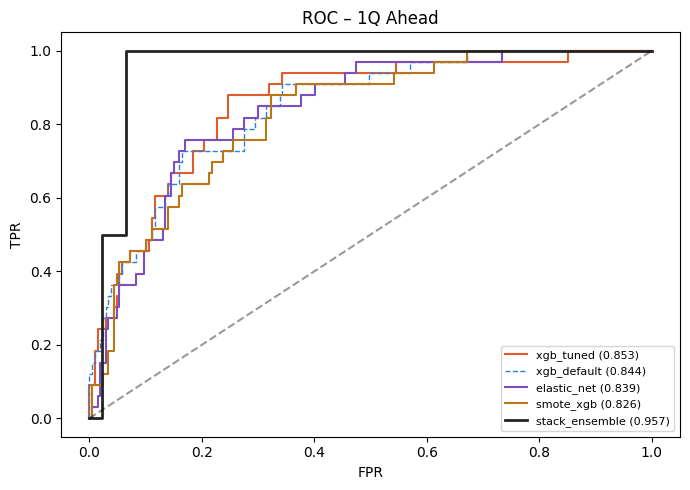

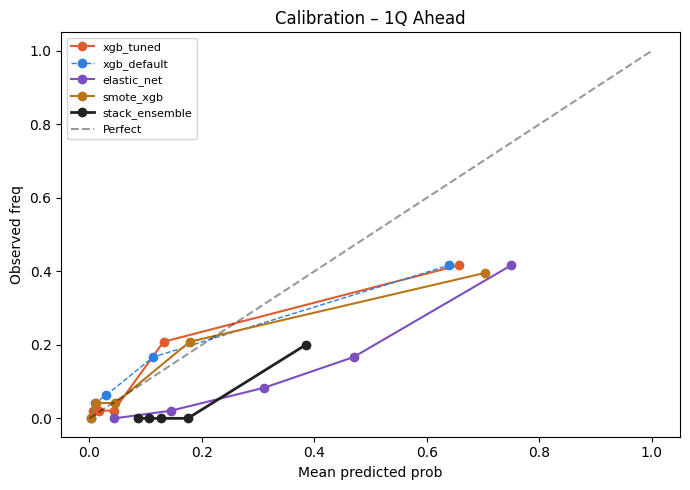

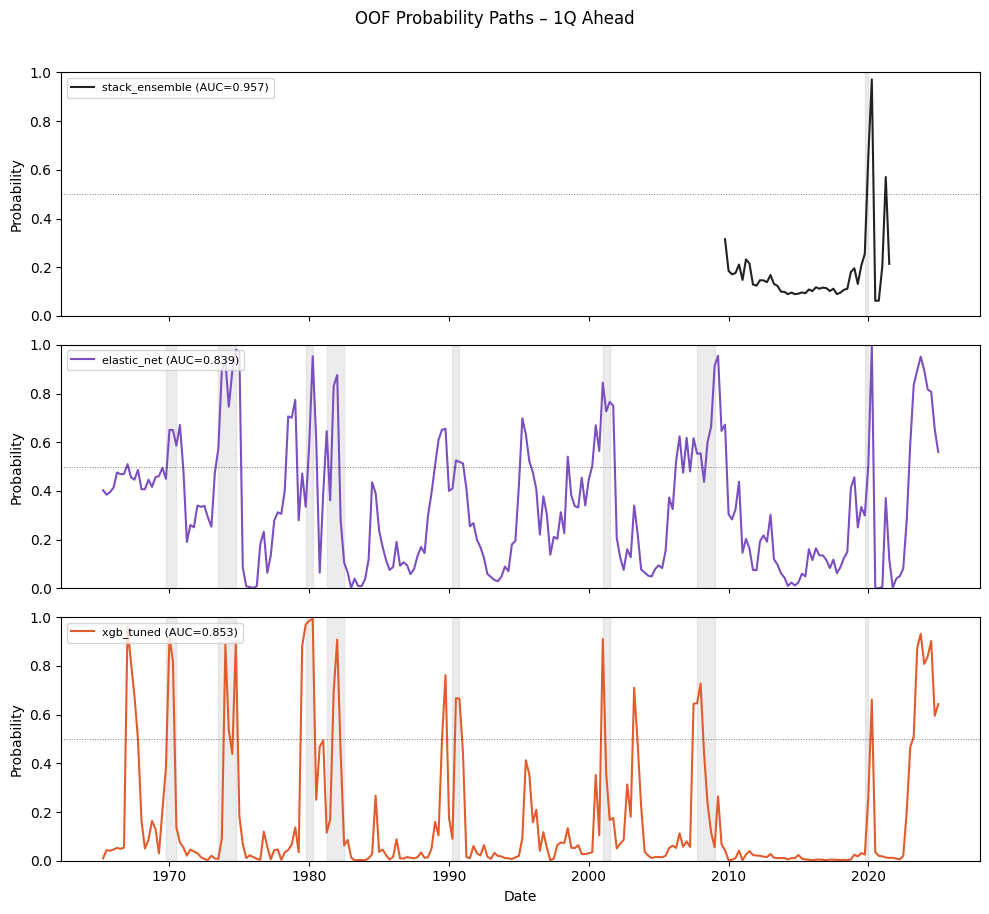

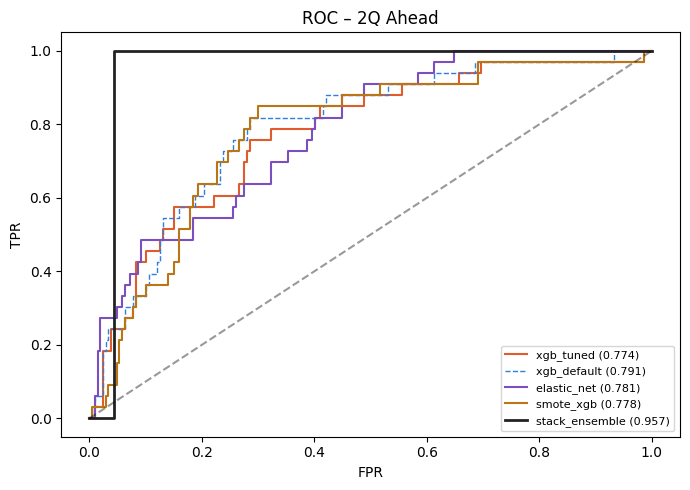

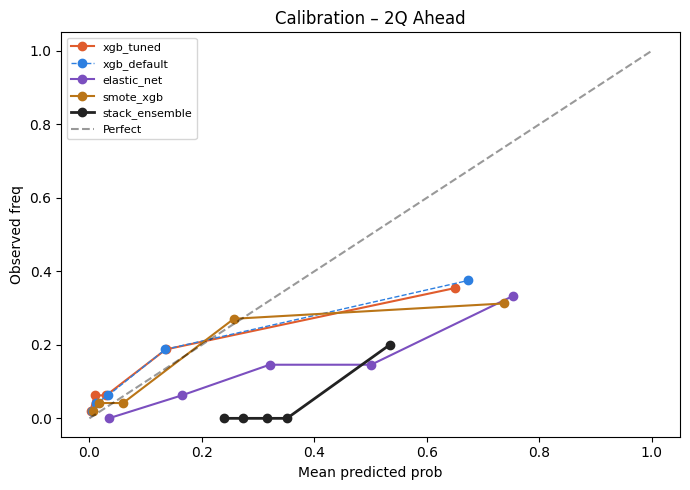

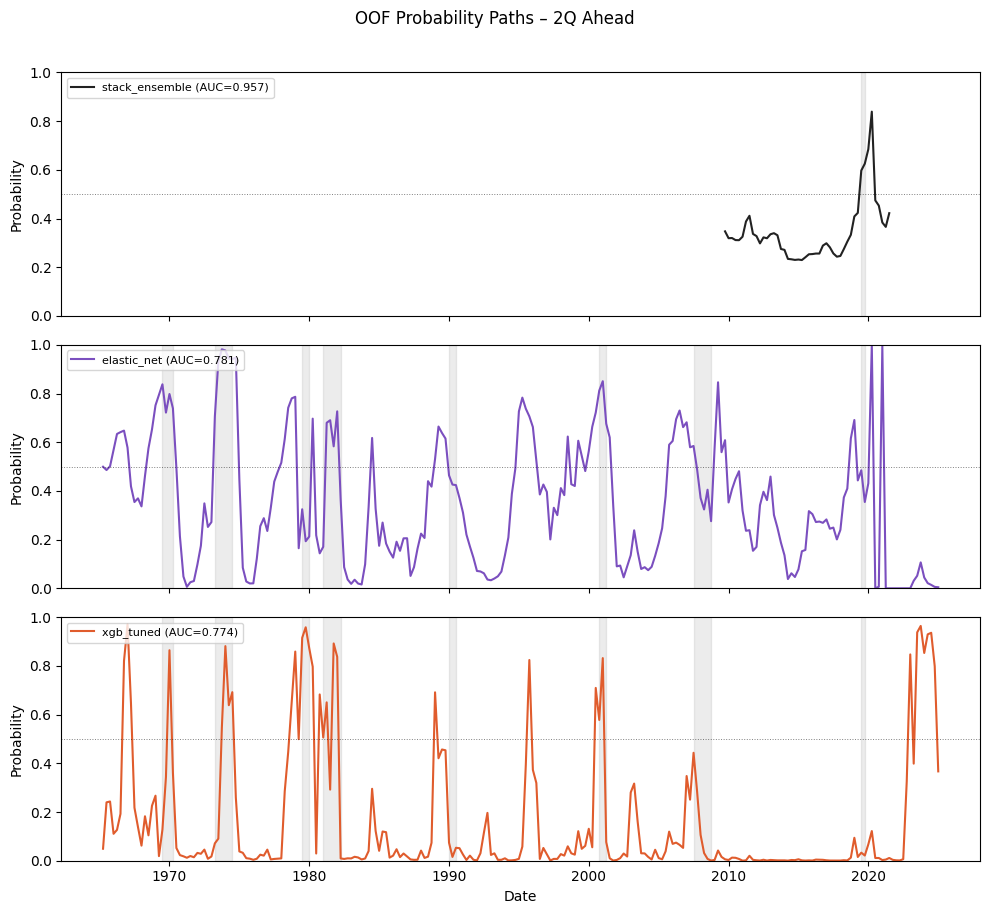

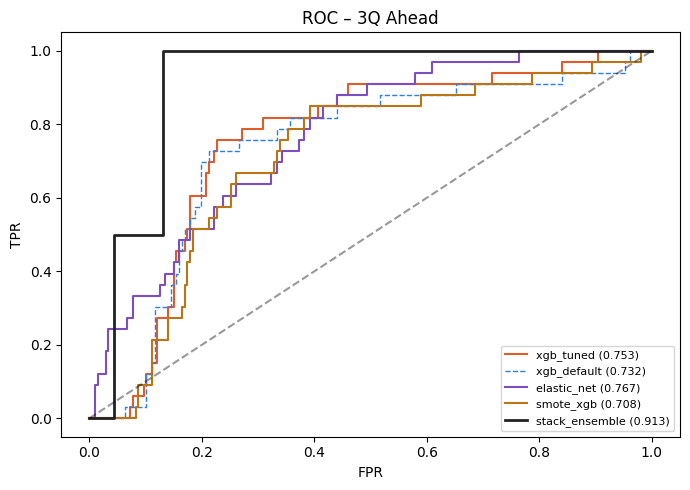

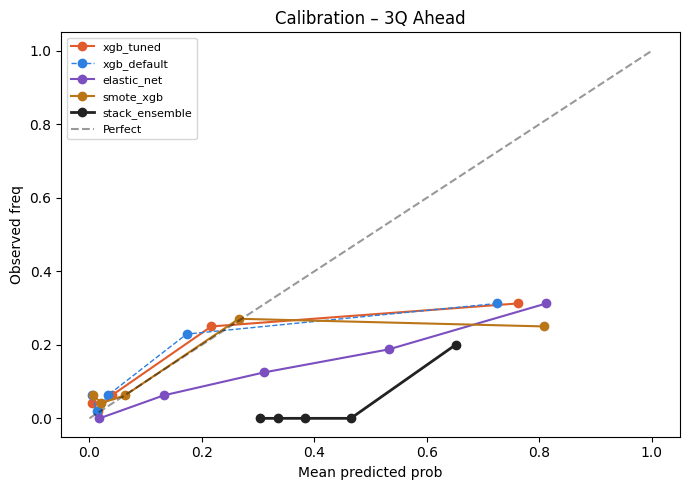

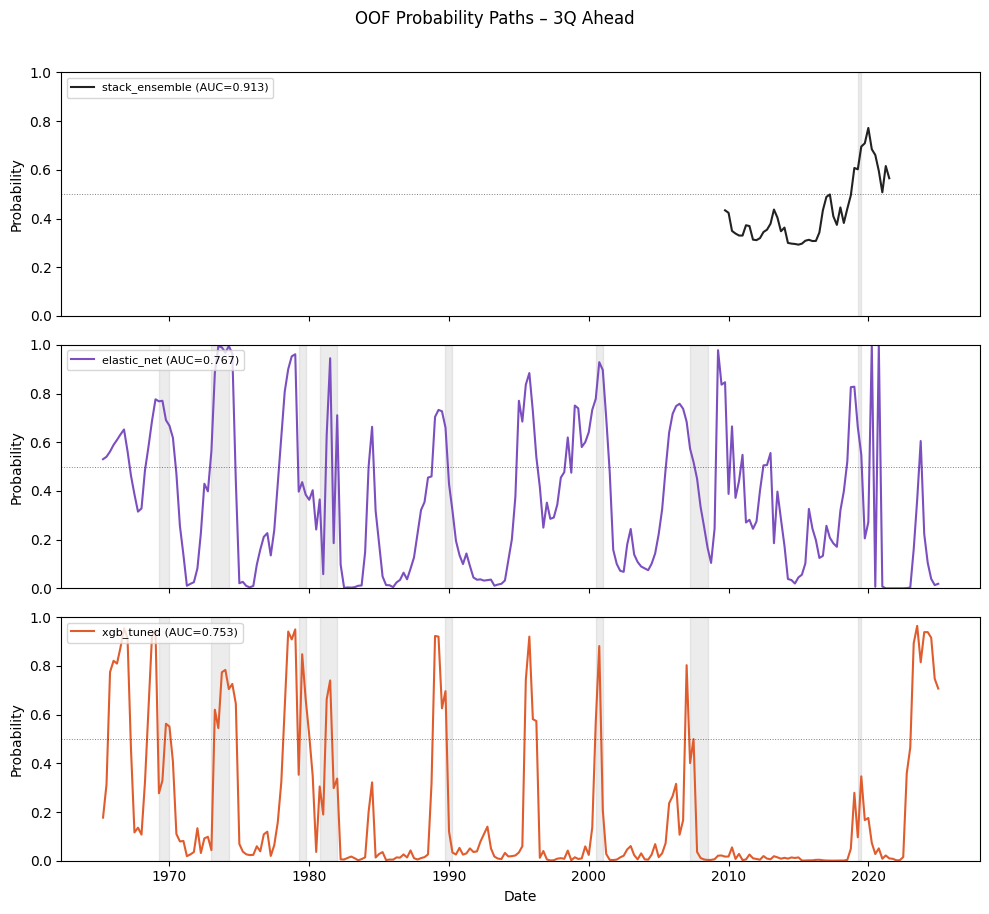

In [26]:
MODEL_STYLES = {
    "xgb_tuned":      {"color": "#e05c2d", "lw": 1.5, "ls": "-"},
    "xgb_default":    {"color": "#2d7fe0", "lw": 1.0, "ls": "--"},
    "elastic_net":    {"color": "#7B4FBF", "lw": 1.5, "ls": "-"},
    "smote_xgb":      {"color": "#BA7517", "lw": 1.5, "ls": "-"},
    "stack_ensemble": {"color": "#222222", "lw": 2.0, "ls": "-"},
}
plot_models = [m for m in MODEL_STYLES if any((h, m) in oof_store for h in horizons)]

for horizon in horizons:
    label = horizon.replace("Target_", "").replace("_ahead", "")
    plt.figure(figsize=(7, 5))
    for mname in plot_models:
        if (horizon, mname) not in oof_store: continue
        frame = oof_store[(horizon, mname)]
        fpr, tpr, _ = roc_curve(frame["y_true"], frame["y_prob"])
        auc_val = roc_auc_score(frame["y_true"], frame["y_prob"])
        s = MODEL_STYLES[mname]
        plt.plot(fpr, tpr, color=s["color"], lw=s["lw"], ls=s["ls"], label=f"{mname} ({auc_val:.3f})")
    plt.plot([0,1],[0,1],"k--",alpha=0.4); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC – {label} Ahead"); plt.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_roc_all.png"), dpi=150); plt.show()

    plt.figure(figsize=(7, 5))
    for mname in plot_models:
        if (horizon, mname) not in oof_store: continue
        frame = oof_store[(horizon, mname)]
        prob_true, prob_pred = calibration_curve(frame["y_true"], frame["y_prob"], n_bins=5, strategy="quantile")
        s = MODEL_STYLES[mname]
        plt.plot(prob_pred, prob_true, marker="o", color=s["color"], lw=s["lw"], ls=s["ls"], label=mname)
    plt.plot([0,1],[0,1],"k--",alpha=0.4,label="Perfect"); plt.xlabel("Mean predicted prob")
    plt.ylabel("Observed freq"); plt.title(f"Calibration – {label} Ahead"); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_calibration_all.png"), dpi=150); plt.show()

    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    for ax, mname in zip(axes, ["stack_ensemble", "elastic_net", "xgb_tuned"]):
        if (horizon, mname) not in oof_store: ax.set_visible(False); continue
        frame = oof_store[(horizon, mname)]; s = MODEL_STYLES[mname]
        auc_val = roc_auc_score(frame["y_true"], frame["y_prob"])
        ax.plot(frame["Date"], frame["y_prob"], color=s["color"], lw=1.5, label=f"{mname} (AUC={auc_val:.3f})")
        ax.fill_between(frame["Date"],0,1,where=frame["y_true"].astype(bool),alpha=0.15,color="grey",transform=ax.get_xaxis_transform())
        ax.axhline(0.5,color="black",ls=":",lw=0.7,alpha=0.5); ax.set_ylim(0,1); ax.set_ylabel("Probability"); ax.legend(fontsize=8,loc="upper left")
    axes[-1].set_xlabel("Date"); fig.suptitle(f"OOF Probability Paths – {label} Ahead",y=1.01)
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR,f"{horizon}_probability_paths.png"),dpi=150,bbox_inches="tight"); plt.show()

## 8.4b – Precision-Recall Curves

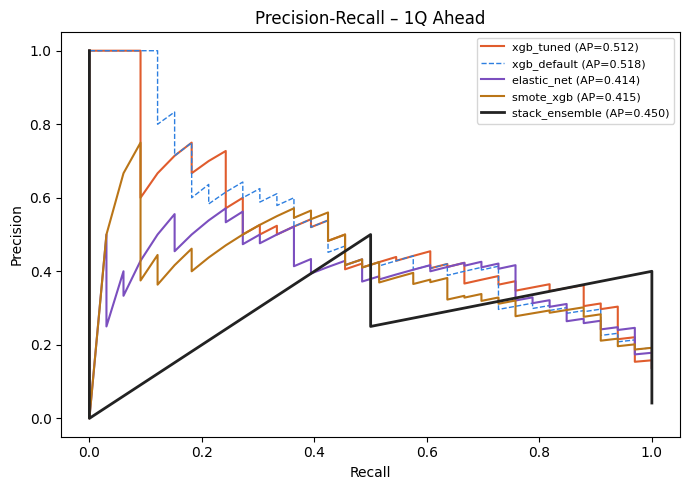

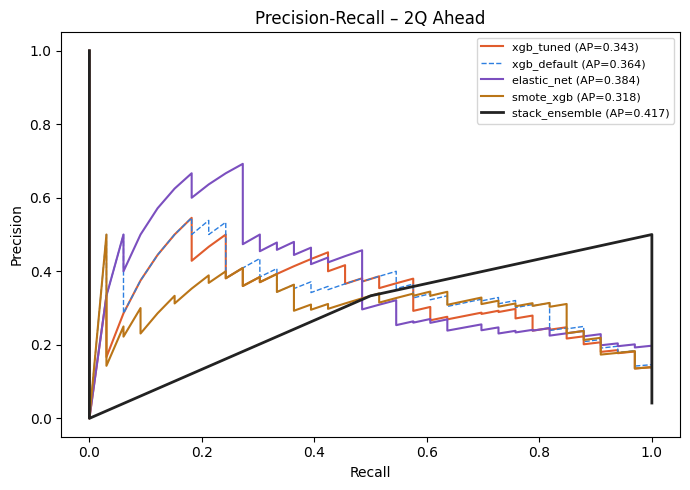

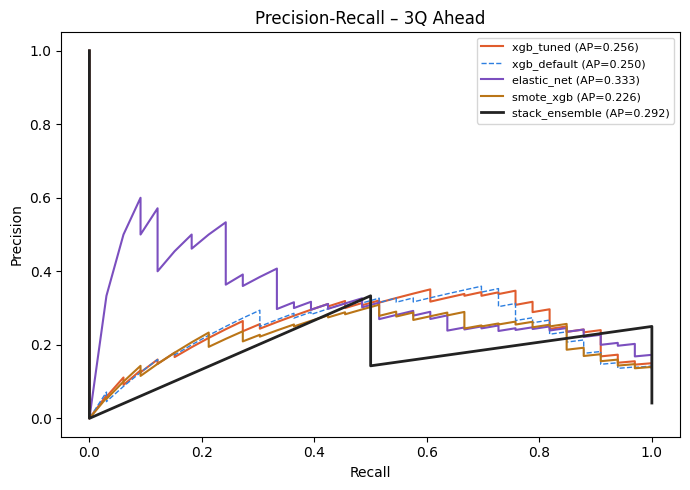

In [27]:
for horizon in horizons:
    label = horizon.replace('Target_', '').replace('_ahead', '')
    plt.figure(figsize=(7, 5))
    for mname in plot_models:
        if (horizon, mname) not in oof_store: continue
        frame = oof_store[(horizon, mname)]
        prec, rec, _ = precision_recall_curve(frame['y_true'], frame['y_prob'])
        ap = average_precision_score(frame['y_true'], frame['y_prob'])
        s = MODEL_STYLES[mname]
        plt.plot(rec, prec, color=s['color'], lw=s['lw'], ls=s['ls'], label=f'{mname} (AP={ap:.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'Precision-Recall – {label} Ahead'); plt.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f'{horizon}_precision_recall.png'), dpi=150)
    plt.show()


## 8.4c – Confusion Matrices (threshold = 0.5)

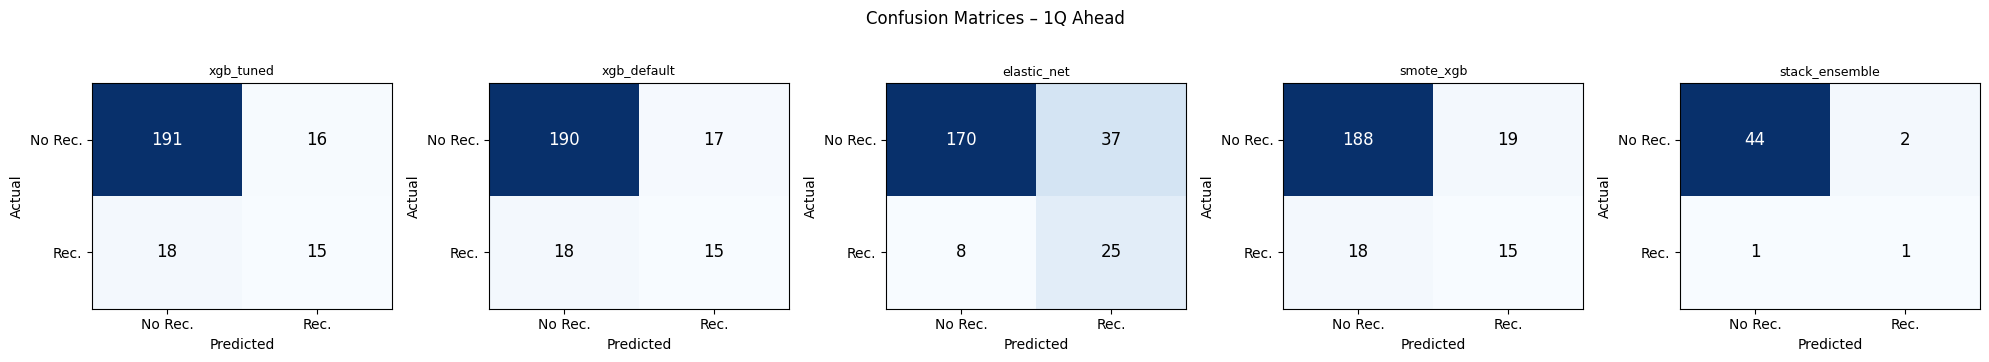

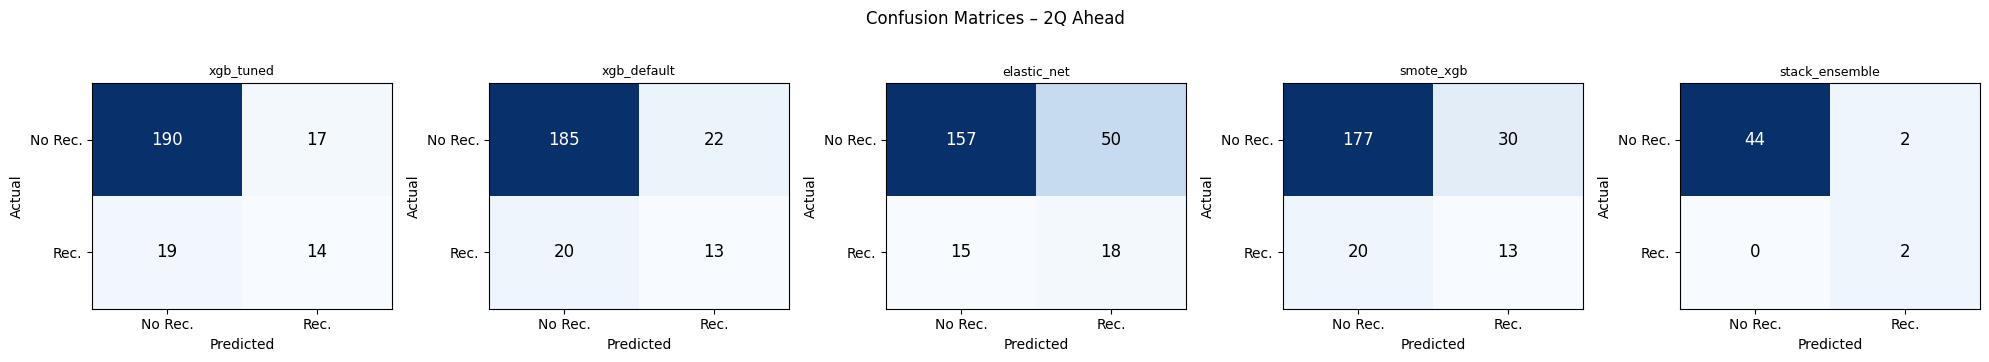

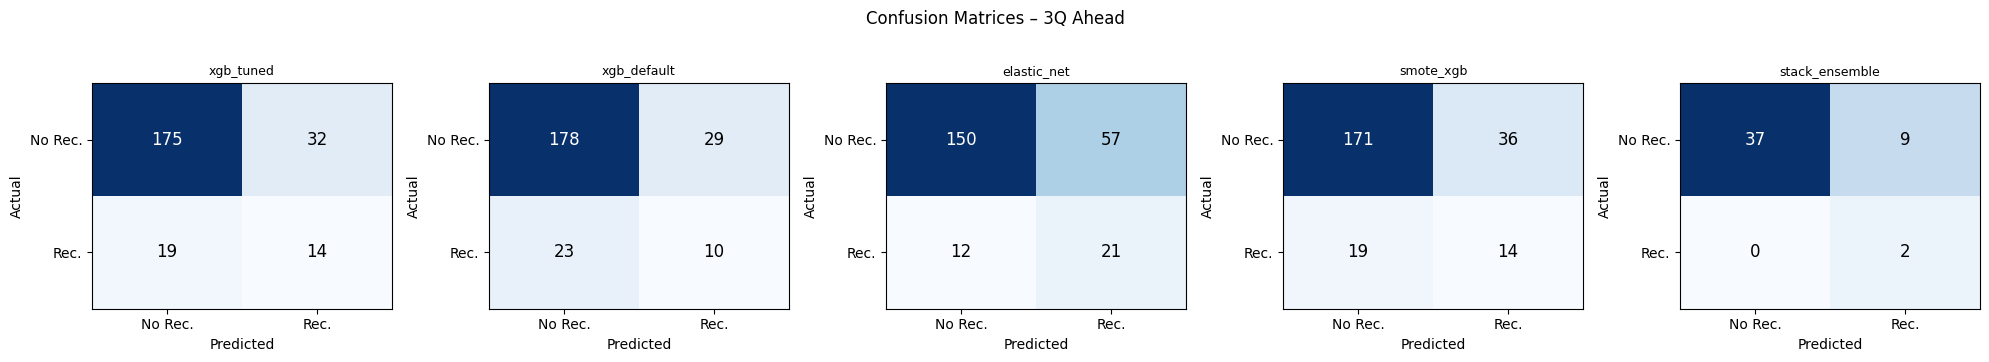

In [28]:
for horizon in horizons:
    label = horizon.replace('Target_', '').replace('_ahead', '')
    n_models = len(plot_models)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 3.5))
    if n_models == 1: axes = [axes]
    for ax, mname in zip(axes, plot_models):
        if (horizon, mname) not in oof_store:
            ax.set_visible(False); continue
        frame = oof_store[(horizon, mname)]
        y_pred = (frame['y_prob'] >= 0.5).astype(int)
        cm = confusion_matrix(frame['y_true'], y_pred, labels=[0, 1])
        ax.imshow(cm, cmap='Blues', aspect='auto')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['No Rec.', 'Rec.']); ax.set_yticklabels(['No Rec.', 'Rec.'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(mname, fontsize=9)
    fig.suptitle(f'Confusion Matrices – {label} Ahead', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f'{horizon}_confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 8.5 – SHAP Feature Importance

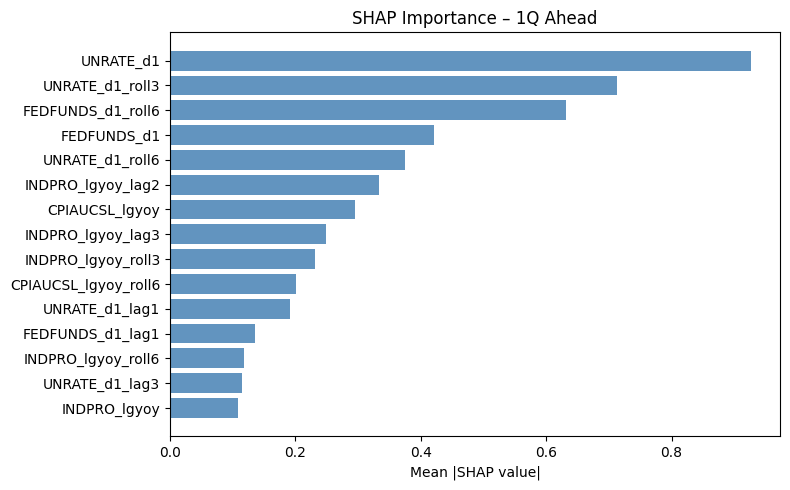

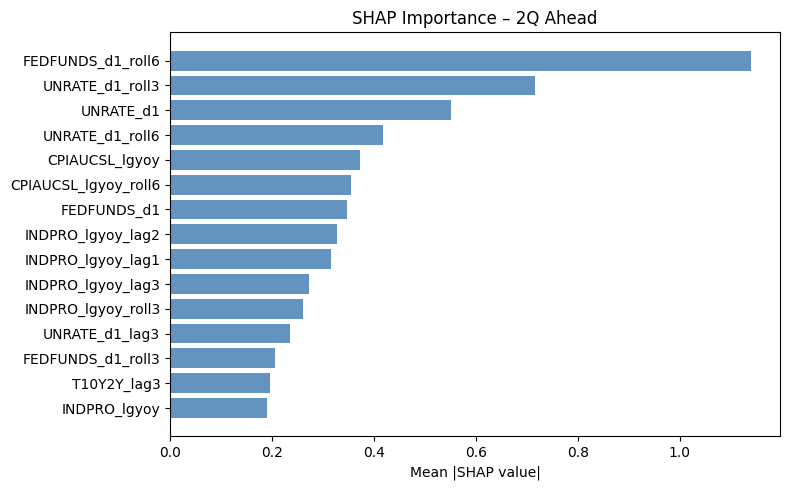

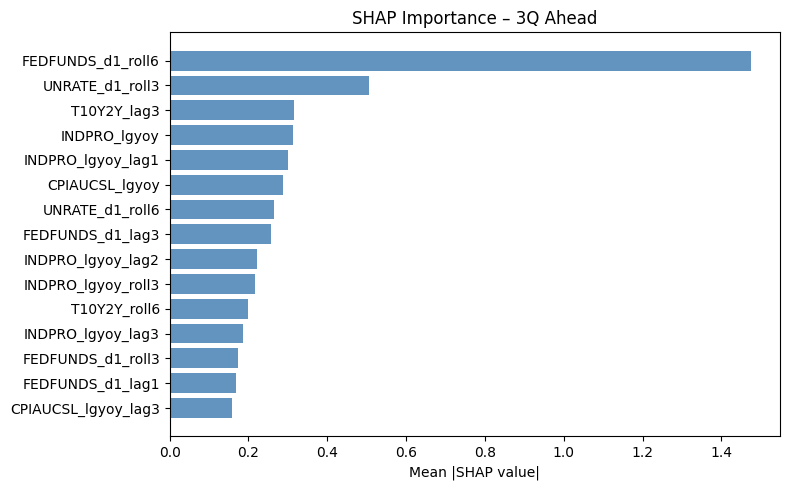

,mean_abs_shap
UNRATE_d1,0.92664
UNRATE_d1_roll3,0.71265
FEDFUNDS_d1_roll6,0.63098
FEDFUNDS_d1,0.42023
UNRATE_d1_roll6,0.37480
INDPRO_lgyoy_lag2,0.33305
CPIAUCSL_lgyoy,0.29431
INDPRO_lgyoy_lag3,0.24857
INDPRO_lgyoy_roll3,0.23131
CPIAUCSL_lgyoy_roll6,0.20150


In [29]:
shap_importance_tables = {}
for horizon in horizons:
    sv = shap_store[(horizon, "xgb_tuned")]["values"]
    mean_abs_shap = np.abs(sv).mean(axis=0)
    shap_table = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
    shap_importance_tables[horizon] = shap_table
    shap_table.to_csv(os.path.join(OUTDIR, f"{horizon}_shap_importance.csv"), header=["mean_abs_shap"])
    label = horizon.replace("Target_","").replace("_ahead","")
    fig, ax = plt.subplots(figsize=(8, 5))
    shap_tbl = shap_table.head(15)
    ax.barh(shap_tbl.index[::-1], shap_tbl.values[::-1], color="steelblue", alpha=0.85)
    ax.set_xlabel("Mean |SHAP value|"); ax.set_title(f"SHAP Importance – {label} Ahead")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_shap_bar.png"), dpi=150); plt.show()
display(shap_importance_tables["Target_1Q_ahead"].head(15).to_frame("mean_abs_shap").round(5))

## 8.6 – SHAP Beeswarm Plots

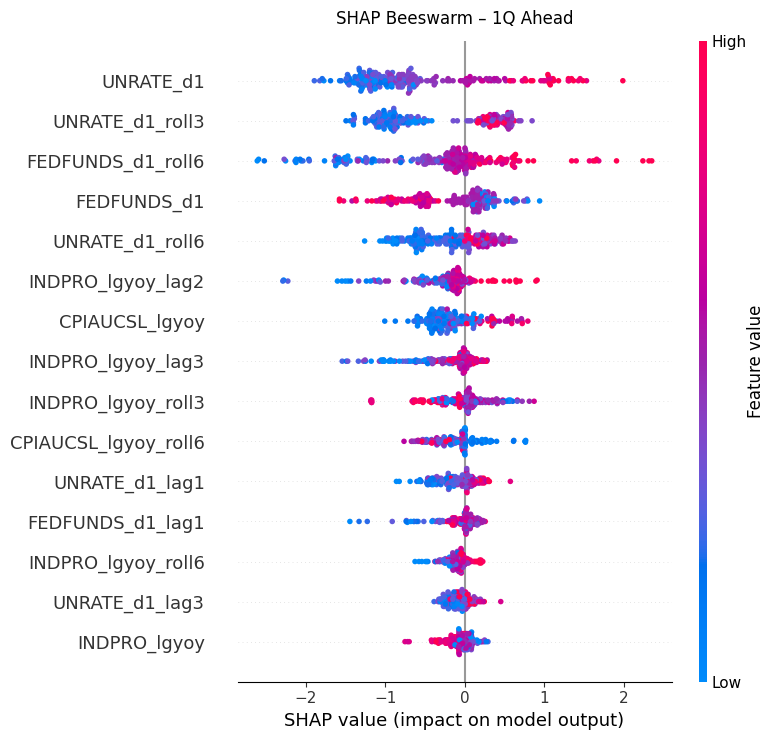

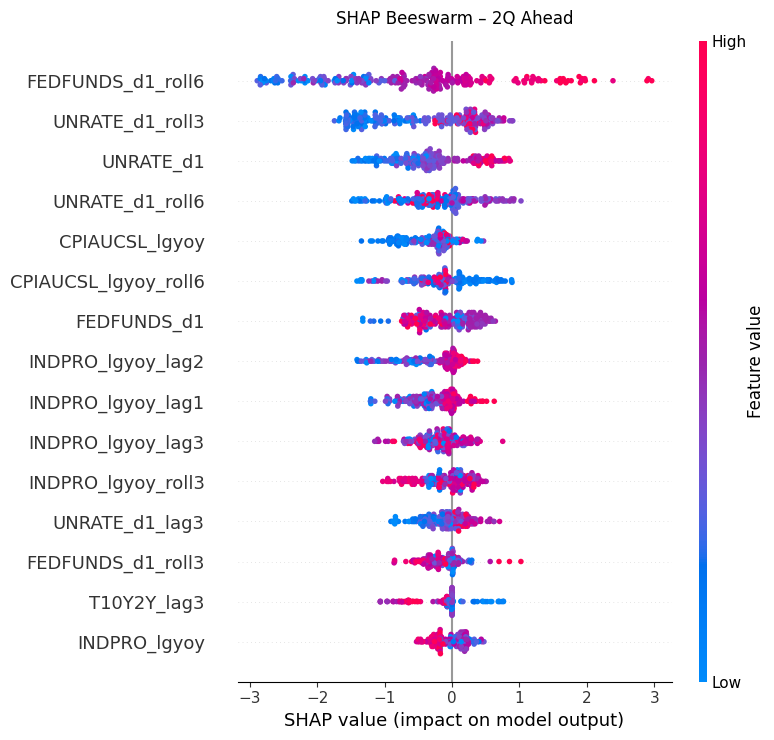

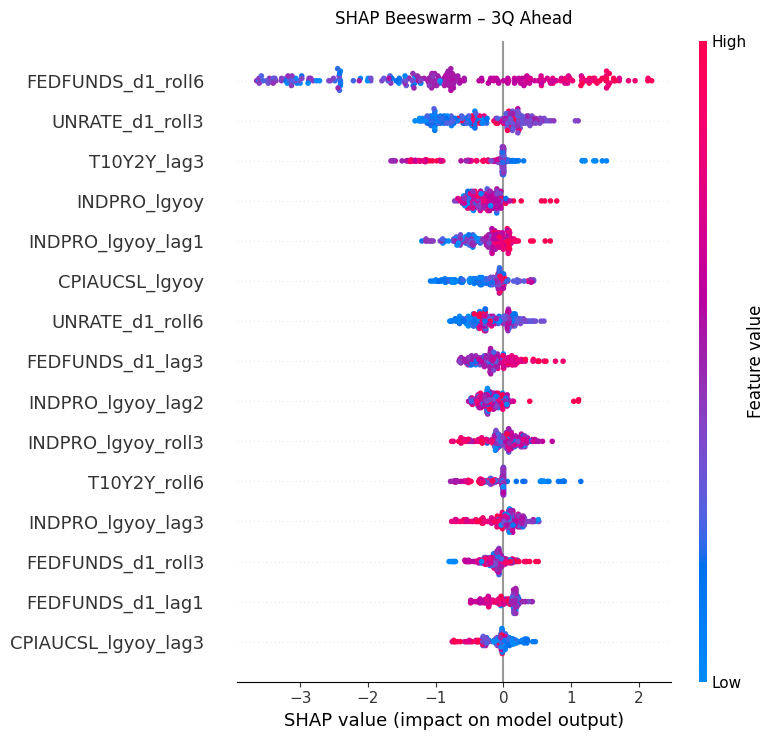

In [30]:
for horizon in horizons:
    label = horizon.replace("Target_","").replace("_ahead","")
    sv = shap_store[(horizon, "xgb_tuned")]["values"]
    X_sh = shap_store[(horizon, "xgb_tuned")]["X"]
    top15_idx = np.argsort(np.abs(sv).mean(axis=0))[::-1][:15]
    shap_exp = shap.Explanation(values=sv[:, top15_idx], data=X_sh[:, top15_idx],
                                 feature_names=[feature_cols[i] for i in top15_idx])
    plt.figure(figsize=(9, 6))
    shap.plots.beeswarm(shap_exp, max_display=15, show=False)
    plt.title(f"SHAP Beeswarm – {label} Ahead", pad=12)
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_shap_beeswarm.png"), dpi=150, bbox_inches="tight"); plt.show()

## 8.6b – SHAP vs Elastic Net Coefficient Comparison

Compares XGBoost SHAP importance rankings with elastic net coefficient magnitudes to check cross-model consistency. High overlap between tree-based and linear importance rankings indicates robust, model-agnostic signal.

In [31]:
# Compare SHAP (xgb_tuned) vs elastic net coefficient magnitude rankings
for horizon in horizons:
    label = horizon.replace('Target_', '').replace('_ahead', '')
    data, X, y = prep_dataset(horizon)
    imp = SimpleImputer(strategy='median'); scaler = StandardScaler()
    Xs = scaler.fit_transform(imp.fit_transform(X.values))
    enet = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                              C=0.5, class_weight='balanced', max_iter=5000, random_state=42)
    enet.fit(Xs, y.values)
    coef_importance = pd.Series(np.abs(enet.coef_[0]), index=feature_cols).sort_values(ascending=False)
    shap_importance = shap_importance_tables[horizon]

    top_n = 15
    shap_top = shap_importance.head(top_n)
    coef_top = coef_importance.head(top_n)
    common = set(shap_top.index) & set(coef_top.index)
    overlap_pct = len(common) / top_n * 100

    compare_df = pd.DataFrame({
        'shap_rank': range(1, top_n + 1), 'shap_feature': shap_top.index.tolist(),
        'coef_rank': range(1, top_n + 1), 'coef_feature': coef_top.index.tolist(),
    })
    print(f'\n{"="*55}\n{label} Ahead — Top-{top_n} Feature Overlap: {overlap_pct:.0f}%\n{"="*55}')
    display(compare_df)
    compare_df.to_csv(os.path.join(OUTDIR, f'{horizon}_shap_vs_coef_comparison.csv'), index=False)



1Q Ahead — Top-15 Feature Overlap: 47%


,shap_rank,shap_feature,coef_rank,coef_feature
0,1,UNRATE_d1,1,T10Y2Y_roll6
1,2,UNRATE_d1_roll3,2,FEDFUNDS_d1_roll6
2,3,FEDFUNDS_d1_roll6,3,BAA10Y
3,4,FEDFUNDS_d1,4,UNRATE_d1_roll6
4,5,UNRATE_d1_roll6,5,UNRATE_d1
5,6,INDPRO_lgyoy_lag2,6,T10Y2Y
6,7,CPIAUCSL_lgyoy,7,T10Y2Y_lag3
7,8,INDPRO_lgyoy_lag3,8,INDPRO_lgyoy_lag3
8,9,INDPRO_lgyoy_roll3,9,FEDFUNDS_d1
9,10,CPIAUCSL_lgyoy_roll6,10,post_2020



2Q Ahead — Top-15 Feature Overlap: 53%


,shap_rank,shap_feature,coef_rank,coef_feature
0,1,FEDFUNDS_d1_roll6,1,post_2020
1,2,UNRATE_d1_roll3,2,FEDFUNDS_d1_roll6
2,3,UNRATE_d1,3,T10Y2Y_roll6
3,4,UNRATE_d1_roll6,4,T10Y2Y
4,5,CPIAUCSL_lgyoy,5,BAA10Y_roll6
5,6,CPIAUCSL_lgyoy_roll6,6,T10Y2Y_lag3
6,7,FEDFUNDS_d1,7,BAA10Y
7,8,INDPRO_lgyoy_lag2,8,UNRATE_d1_roll6
8,9,INDPRO_lgyoy_lag1,9,UNRATE_d1_lag3
9,10,INDPRO_lgyoy_lag3,10,BAA10Y_lag2



3Q Ahead — Top-15 Feature Overlap: 40%


,shap_rank,shap_feature,coef_rank,coef_feature
0,1,FEDFUNDS_d1_roll6,1,FEDFUNDS_d1_roll6
1,2,UNRATE_d1_roll3,2,post_2020
2,3,T10Y2Y_lag3,3,T10Y2Y_roll6
3,4,INDPRO_lgyoy,4,T10Y2Y_lag3
4,5,INDPRO_lgyoy_lag1,5,T10Y2Y
5,6,CPIAUCSL_lgyoy,6,BAA10Y_lag3
6,7,UNRATE_d1_roll6,7,INDPRO_lgyoy_lag1
7,8,FEDFUNDS_d1_lag3,8,BAA10Y
8,9,INDPRO_lgyoy_lag2,9,BAA10Y_roll6
9,10,INDPRO_lgyoy_roll3,10,BAA10Y_roll3


## 8.7 – Hyperparameter Summary

In [32]:
for horizon in horizons:
    label = horizon.replace("Target_","").replace("_ahead","")
    param_df = pd.DataFrame(best_params_store[(horizon, "xgb_tuned")])
    summary  = pd.DataFrame({"mode": param_df.mode().iloc[0], "mean": param_df.mean().round(4)})
    print(f"\nBest XGB hyperparameters — {label} Ahead:"); display(summary)
    summary.to_csv(os.path.join(OUTDIR, f"{horizon}_best_params.csv"))


Best XGB hyperparameters — 1Q Ahead:


,mode,mean
colsample_bytree,0.80,0.8000
learning_rate,0.05,0.0633
max_depth,3.00,2.7000
n_estimators,200.00,273.3333
reg_alpha,0.10,0.5200
reg_lambda,5.00,4.2000
subsample,0.80,0.8000



Best XGB hyperparameters — 2Q Ahead:


,mode,mean
colsample_bytree,0.8,0.8000
learning_rate,0.1,0.0783
max_depth,2.0,2.4333
n_estimators,200.0,300.0000
reg_alpha,0.1,0.3400
reg_lambda,1.0,2.2000
subsample,0.8,0.8000



Best XGB hyperparameters — 3Q Ahead:


,mode,mean
colsample_bytree,0.80,0.8000
learning_rate,0.05,0.0750
max_depth,2.00,2.4333
n_estimators,200.00,233.3333
reg_alpha,0.10,0.4900
reg_lambda,5.00,3.4000
subsample,0.80,0.8000


## 8.8 – Comparison vs Team A

In [33]:
TEAM_A_PATH = os.path.join("model_team_a_outputs", "model_comparison.csv")
if os.path.exists(TEAM_A_PATH):
    team_a_df = pd.read_csv(TEAM_A_PATH); team_a_df["team"] = "Team_A (LogReg)"
    results_df["team"] = "Team_B (XGBoost+)"
    combined = pd.concat([team_a_df, results_df], ignore_index=True).sort_values(["horizon","team","model"])
    display(combined[["team","model","horizon","auc","average_precision","brier","log_loss"]].round(4))
    combined.to_csv(os.path.join(OUTDIR, "combined_team_comparison.csv"), index=False)
else:
    print("Team A outputs not found."); display(results_df.round(4))

,team,model,horizon,auc,average_precision,brier,log_loss
0,Team_A (LogReg),full_l2,1Q,0.9253,0.4235,0.0981,1.0047
3,Team_A (LogReg),sparse_l1,1Q,0.9531,0.6282,0.0755,0.5739
6,Team_B (XGBoost+),elastic_net,1Q,0.8393,0.4137,0.1507,0.5948
7,Team_B (XGBoost+),smote_xgb,1Q,0.8258,0.4153,0.1186,0.3871
8,Team_B (XGBoost+),stack_ensemble,1Q,0.9565,0.4500,0.0603,0.2667
9,Team_B (XGBoost+),xgb_default,1Q,0.8437,0.5183,0.1060,0.3459
10,Team_B (XGBoost+),xgb_tuned,1Q,0.8535,0.5123,0.1057,0.3363
1,Team_A (LogReg),full_l2,2Q,0.8351,0.4443,0.1215,0.5042
4,Team_A (LogReg),sparse_l1,2Q,0.9219,0.5429,0.0958,0.3229
11,Team_B (XGBoost+),elastic_net,2Q,0.7811,0.3836,0.1696,0.5786


# 9 – Robustness Across Regimes

Tests performance stability across four macroeconomic eras. A model is flagged as potentially overfit if its AUC in one regime exceeds the mean of all other regimes by ≥0.10.

## 9.1 – Regime Definitions

In [34]:
# With data extending back to 1948, we can define three macroeconomic eras.
# The walk-forward window starts after ~60 initial quarters (≈1963), so
# all three regimes should have OOF data.
REGIMES = {
    "pre_Volcker":     (pd.Timestamp("1900-01-01"), pd.Timestamp("1979-12-31")),
    "Volcker_to_GFC":  (pd.Timestamp("1980-01-01"), pd.Timestamp("2007-12-31")),
    "post_GFC":        (pd.Timestamp("2008-01-01"), pd.Timestamp("2099-12-31")),
}
ROBUST_MODELS = ["elastic_net", "xgb_tuned", "smote_xgb", "stack_ensemble"]
MIN_POSITIVES = 2
print("Regimes: pre-Volcker / Volcker-to-GFC / post-GFC")
print(f"MIN_POSITIVES = {MIN_POSITIVES}")
for name, (start, end) in REGIMES.items():
    print(f"  {name:20s}  {start.date()} → {end.date()}")


Regimes: pre-Volcker / Volcker-to-GFC / post-GFC
MIN_POSITIVES = 2
  pre_Volcker           1900-01-01 → 1979-12-31
  Volcker_to_GFC        1980-01-01 → 2007-12-31
  post_GFC              2008-01-01 → 2099-12-31


## 9.2 – Per-Regime Metrics

In [35]:
def regime_metrics(frame, start, end):
    mask = (frame["Date"] >= start) & (frame["Date"] <= end)
    sub  = frame[mask]
    n_pos, n_obs = int(sub["y_true"].sum()), len(sub)
    if n_obs < 8 or len(sub["y_true"].unique()) < 2:
        return {"auc": np.nan, "ap": np.nan, "brier": np.nan, "n_obs": n_obs, "n_pos": n_pos, "reliable": False}
    return {"auc": roc_auc_score(sub["y_true"], sub["y_prob"]),
            "ap":  average_precision_score(sub["y_true"], sub["y_prob"]),
            "brier": brier_score_loss(sub["y_true"], sub["y_prob"]),
            "n_obs": n_obs, "n_pos": n_pos, "reliable": n_pos >= MIN_POSITIVES}

regime_rows = []
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    for mname in ROBUST_MODELS:
        if (horizon, mname) not in oof_store: continue
        frame = oof_store[(horizon, mname)]
        for regime, (r_start, r_end) in REGIMES.items():
            regime_rows.append({"horizon": h_label, "model": mname, "regime": regime,
                                 **regime_metrics(frame, r_start, r_end)})
regime_df = pd.DataFrame(regime_rows)
display(regime_df[["horizon","model","regime","n_obs","n_pos","auc","ap","brier","reliable"]].round(4))
regime_df.to_csv(os.path.join(OUTDIR, "regime_robustness_raw.csv"), index=False)

,horizon,model,regime,n_obs,n_pos,auc,ap,brier,reliable
0,1Q,elastic_net,pre_Volcker,59,11,0.8655,0.6330,0.1688,True
1,1Q,elastic_net,Volcker_to_GFC,112,15,0.8440,0.6118,0.1293,True
2,1Q,elastic_net,post_GFC,69,7,0.8041,0.2421,0.1700,True
3,1Q,xgb_tuned,pre_Volcker,59,11,0.8428,0.6262,0.1159,True
4,1Q,xgb_tuned,Volcker_to_GFC,112,15,0.8976,0.6584,0.0782,True
5,1Q,xgb_tuned,post_GFC,69,7,0.8134,0.2419,0.1414,True
6,1Q,smote_xgb,pre_Volcker,59,11,0.7765,0.4591,0.1402,True
7,1Q,smote_xgb,Volcker_to_GFC,112,15,0.8832,0.6677,0.0894,True
8,1Q,smote_xgb,post_GFC,69,7,0.7719,0.2200,0.1475,True
9,1Q,stack_ensemble,pre_Volcker,0,0,NaN,NaN,NaN,False


## 9.3 – AUC Heatmap

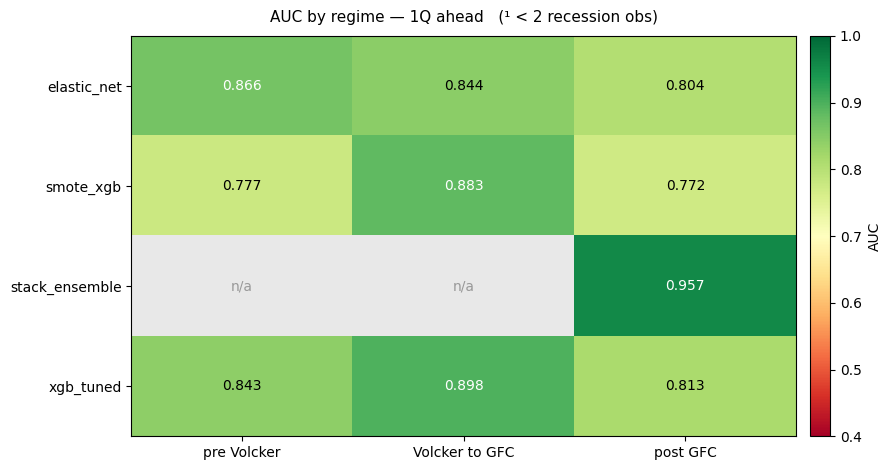

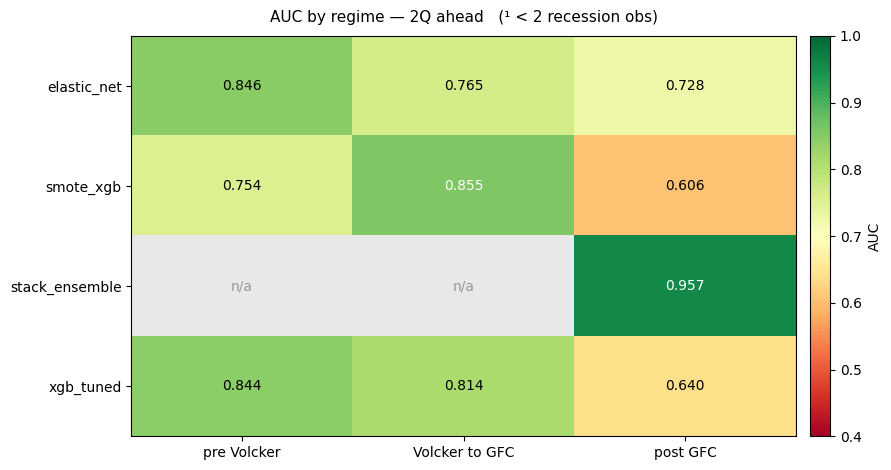

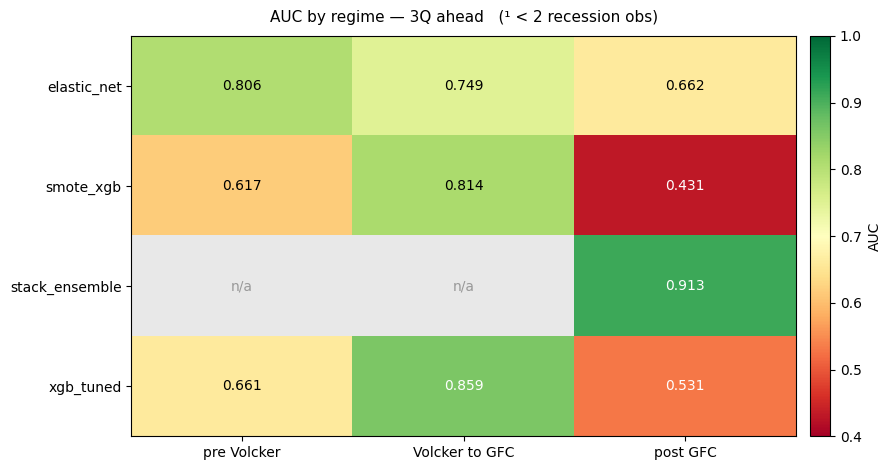

In [36]:
regime_order = list(REGIMES.keys())
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    sub = regime_df[regime_df["horizon"] == h_label].copy()
    pivot_auc = sub.pivot(index="model", columns="regime", values="auc")[regime_order]
    pivot_rel = sub.pivot(index="model", columns="regime", values="reliable")[regime_order]
    fig, ax = plt.subplots(figsize=(9, len(ROBUST_MODELS) * 0.9 + 1.2))
    data_arr = pivot_auc.values.astype(float); rel_arr = pivot_rel.values
    masked = np.ma.masked_invalid(data_arr)
    cmap = plt.cm.RdYlGn; cmap.set_bad(color="#e8e8e8")
    im = ax.imshow(masked, cmap=cmap, vmin=0.4, vmax=1.0, aspect="auto")
    for i in range(data_arr.shape[0]):
        for j in range(data_arr.shape[1]):
            val = data_arr[i, j]
            if np.isnan(val): ax.text(j,i,"n/a",ha="center",va="center",fontsize=10,color="#999")
            else:
                reliable = bool(rel_arr[i,j]) if rel_arr[i,j] is not None else False
                txt = f"{val:.3f}" + ("" if reliable else "\u00b9")
                color = "white" if val < 0.6 or val > 0.85 else "black"
                ax.text(j,i,txt,ha="center",va="center",fontsize=10,color=color)
    ax.set_xticks(range(len(regime_order)))
    ax.set_xticklabels([r.replace("_"," ") for r in regime_order], fontsize=10)
    ax.set_yticks(range(len(pivot_auc.index))); ax.set_yticklabels(pivot_auc.index, fontsize=10)
    ax.set_title(f"AUC by regime — {h_label} ahead   (¹ < {MIN_POSITIVES} recession obs)", fontsize=11, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="AUC")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_regime_auc_heatmap.png"), dpi=150); plt.show()

## 9.4 – Stability Scores

In [37]:
stability_rows = []
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    sub = regime_df[(regime_df["horizon"] == h_label) & (regime_df["reliable"] == True)]
    for mname in ROBUST_MODELS:
        m_sub = sub[sub["model"] == mname]["auc"].dropna()
        if len(m_sub) < 2: continue
        stability_rows.append({"horizon": h_label, "model": mname, "mean_auc": m_sub.mean(),
                                "std_auc": m_sub.std(), "min_auc": m_sub.min(), "max_auc": m_sub.max(),
                                "auc_range": m_sub.max() - m_sub.min(), "n_regimes": len(m_sub)})
if stability_rows:
    stability_df = pd.DataFrame(stability_rows).sort_values(["horizon","std_auc"])
    print("Stability scores (lower std = more stable):"); display(stability_df.round(4))
    stability_df.to_csv(os.path.join(OUTDIR, "regime_stability_scores.csv"), index=False)
else:
    stability_df = pd.DataFrame(columns=["horizon","model","mean_auc","std_auc","min_auc","max_auc","auc_range","n_regimes"])
    print("No models had reliable AUC in >= 2 regimes — stability analysis skipped.")

Stability scores (lower std = more stable):


,horizon,model,mean_auc,std_auc,min_auc,max_auc,auc_range,n_regimes
0,1Q,elastic_net,0.8379,0.0311,0.8041,0.8655,0.0614,3
1,1Q,xgb_tuned,0.8513,0.0427,0.8134,0.8976,0.0842,3
2,1Q,smote_xgb,0.8105,0.0630,0.7719,0.8832,0.1113,3
3,2Q,elastic_net,0.7794,0.0604,0.7275,0.8457,0.1182,3
4,2Q,xgb_tuned,0.7662,0.1101,0.6402,0.8440,0.2038,3
5,2Q,smote_xgb,0.7381,0.1253,0.6058,0.8550,0.2492,3
6,3Q,elastic_net,0.7392,0.0723,0.6625,0.8060,0.1435,3
7,3Q,xgb_tuned,0.6836,0.1651,0.5312,0.8591,0.3279,3
8,3Q,smote_xgb,0.6207,0.1913,0.4312,0.8137,0.3825,3


## 9.5 – Overfitting Flags

In [38]:
OVERFIT_THRESHOLD = 0.10
overfit_flags = []
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    sub = regime_df[(regime_df["horizon"] == h_label) & (regime_df["reliable"] == True)]
    for mname in ROBUST_MODELS:
        m_sub = sub[sub["model"] == mname][["regime","auc"]].dropna()
        if len(m_sub) < 3: continue
        for _, row in m_sub.iterrows():
            others_mean = m_sub[m_sub["regime"] != row["regime"]]["auc"].mean()
            uplift = row["auc"] - others_mean
            if uplift >= OVERFIT_THRESHOLD:
                overfit_flags.append({"horizon": h_label, "model": mname, "regime": row["regime"],
                                      "regime_auc": row["auc"], "others_mean": others_mean, "uplift": uplift})
if overfit_flags:
    flags_df = pd.DataFrame(overfit_flags).sort_values("uplift", ascending=False)
    display(flags_df.round(4)); flags_df.to_csv(os.path.join(OUTDIR, "overfit_flags.csv"), index=False)
else:
    print("No overfitting flags detected.")

,horizon,model,regime,regime_auc,others_mean,uplift
5,3Q,smote_xgb,Volcker_to_GFC,0.8137,0.5242,0.2896
4,3Q,xgb_tuned,Volcker_to_GFC,0.8591,0.5959,0.2632
2,2Q,smote_xgb,Volcker_to_GFC,0.8550,0.6797,0.1753
1,2Q,xgb_tuned,pre_Volcker,0.8440,0.7273,0.1166
0,1Q,smote_xgb,Volcker_to_GFC,0.8832,0.7742,0.1090
3,3Q,elastic_net,pre_Volcker,0.8060,0.7058,0.1002


## 9.6 – AUC Line Plot

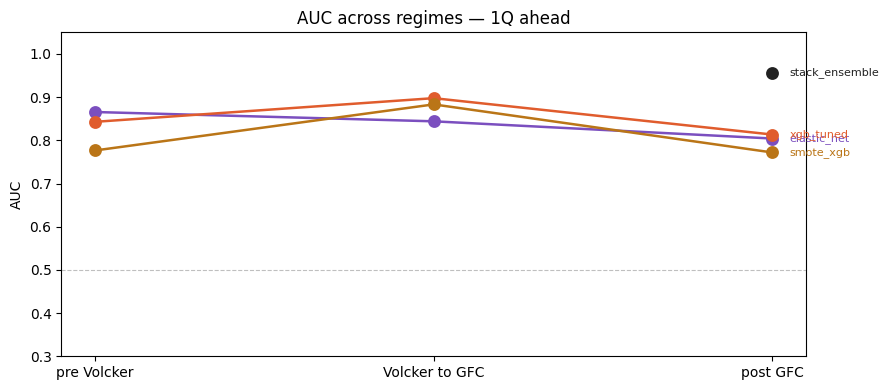

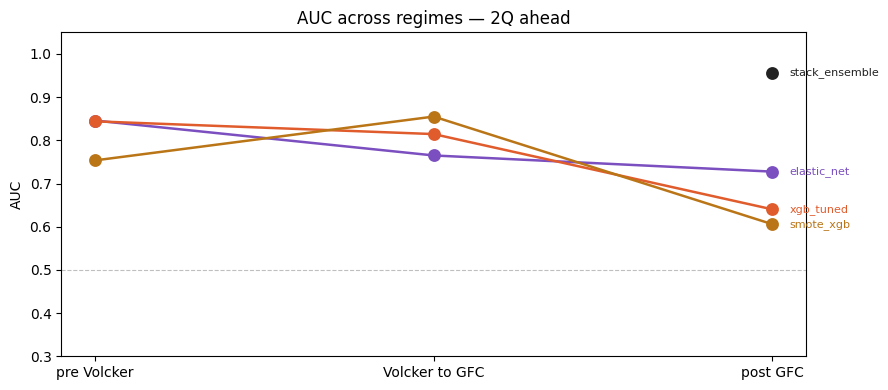

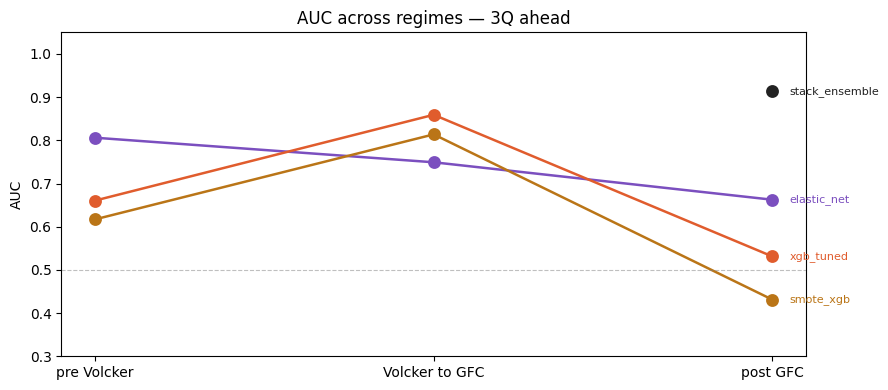

In [39]:
ROBUST_COLORS = {"elastic_net": "#7B4FBF", "xgb_tuned": "#e05c2d",
                 "smote_xgb": "#BA7517", "stack_ensemble": "#222222"}
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    sub = regime_df[regime_df["horizon"] == h_label]
    fig, ax = plt.subplots(figsize=(9, 4))
    for mname in ROBUST_MODELS:
        m_sub = sub[sub["model"] == mname].set_index("regime").reindex(regime_order)
        aucs = m_sub["auc"].values; reliable = m_sub["reliable"].values
        color = ROBUST_COLORS.get(mname, "gray")
        for i in range(len(regime_order) - 1):
            if np.isnan(aucs[i]) or np.isnan(aucs[i+1]): continue
            ax.plot([i, i+1], [aucs[i], aucs[i+1]], color=color, lw=1.8,
                    ls="-" if (reliable[i] and reliable[i+1]) else ":")
        for i, (auc_val, rel) in enumerate(zip(aucs, reliable)):
            if np.isnan(auc_val): continue
            ax.scatter(i, auc_val, color=color, s=60, zorder=5, marker="o" if rel else "^",
                       facecolors=color if rel else "white", edgecolors=color, lw=1.5)
        last_valid = [(i, v) for i, v in enumerate(aucs) if not np.isnan(v)]
        if last_valid: ax.text(last_valid[-1][0]+0.05, last_valid[-1][1], mname, fontsize=8, color=color, va="center")
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(range(len(regime_order)))
    ax.set_xticklabels([r.replace("_"," ") for r in regime_order], fontsize=10)
    ax.set_ylabel("AUC"); ax.set_ylim(0.3, 1.05); ax.set_title(f"AUC across regimes — {h_label} ahead")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_regime_auc_lineplot.png"), dpi=150); plt.show()

## 9.7 – Brier Score by Regime

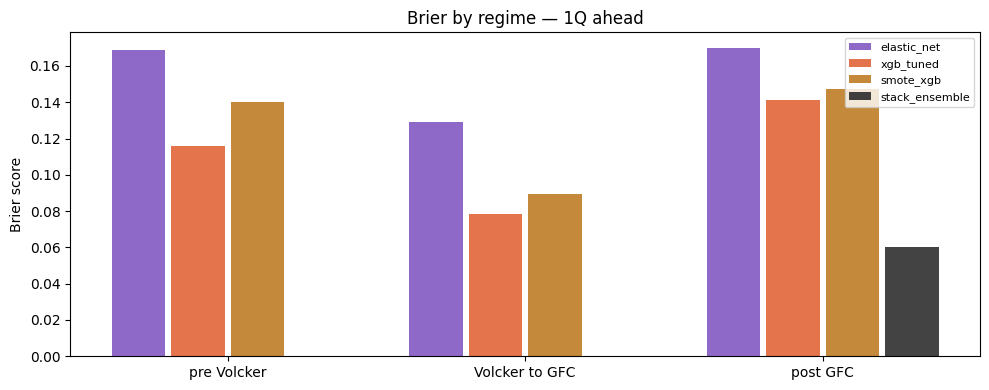

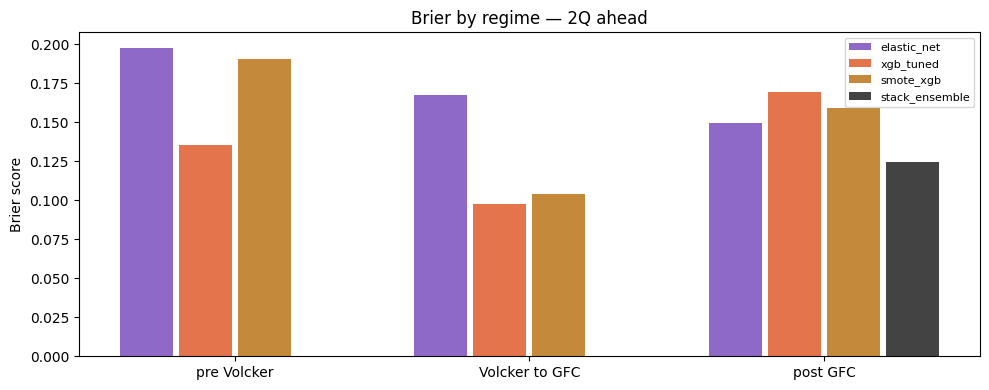

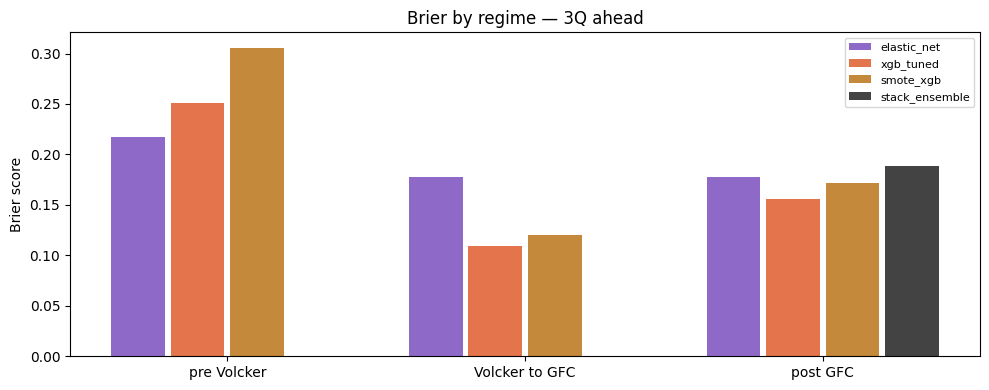

In [40]:
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    sub = regime_df[regime_df["horizon"] == h_label]
    pivot_brier = sub.pivot(index="model", columns="regime", values="brier")[regime_order]
    pivot_brier = pivot_brier.reindex(ROBUST_MODELS).dropna(how="all")
    x = np.arange(len(regime_order)); width = 0.2
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, mname in enumerate(pivot_brier.index):
        vals = pivot_brier.loc[mname].values.astype(float)
        offset = (i - len(pivot_brier.index) / 2 + 0.5) * width
        ax.bar(x + offset, np.where(np.isnan(vals), 0, vals),
               width=width*0.9, color=ROBUST_COLORS.get(mname, "gray"), alpha=0.85, label=mname)
    ax.set_xticks(x); ax.set_xticklabels([r.replace("_"," ") for r in regime_order], fontsize=10)
    ax.set_ylabel("Brier score"); ax.set_title(f"Brier by regime — {h_label} ahead")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_regime_brier_bars.png"), dpi=150); plt.show()

## 9.8 – Regime Robustness Summary

In [41]:
print("="*70, "\nREGIME ROBUSTNESS SUMMARY\n" + "="*70)
for horizon in horizons:
    h_label = horizon.replace("Target_","").replace("_ahead","")
    print(f"\n--- {h_label} ahead ---")
    sub_stab = stability_df[stability_df["horizon"] == h_label]
    if sub_stab.empty: print("  Insufficient data."); continue
    most_stable = sub_stab.sort_values("std_auc").iloc[0]
    print(f"  Most stable:   {most_stable['model']}  (std={most_stable['std_auc']:.3f}, range={most_stable['auc_range']:.3f})")
    best_mean = sub_stab.sort_values("mean_auc", ascending=False).iloc[0]
    print(f"  Best mean AUC: {best_mean['model']}  (mean={best_mean['mean_auc']:.3f})")
    if overfit_flags:
        h_flags = [f for f in overfit_flags if f["horizon"] == h_label]
        if h_flags:
            print(f"  Overfit flags ({len(h_flags)}):")
            for f in h_flags: print(f"    {f['model']:20s} in {f['regime']:12s}  uplift={f['uplift']:.3f}")
        else: print("  No overfit flags.")

REGIME ROBUSTNESS SUMMARY

--- 1Q ahead ---
  Most stable:   elastic_net  (std=0.031, range=0.061)
  Best mean AUC: xgb_tuned  (mean=0.851)
  Overfit flags (1):
    smote_xgb            in Volcker_to_GFC  uplift=0.109

--- 2Q ahead ---
  Most stable:   elastic_net  (std=0.060, range=0.118)
  Best mean AUC: elastic_net  (mean=0.779)
  Overfit flags (2):
    xgb_tuned            in pre_Volcker   uplift=0.117
    smote_xgb            in Volcker_to_GFC  uplift=0.175

--- 3Q ahead ---
  Most stable:   elastic_net  (std=0.072, range=0.144)
  Best mean AUC: elastic_net  (mean=0.739)
  Overfit flags (3):
    elastic_net          in pre_Volcker   uplift=0.100
    xgb_tuned            in Volcker_to_GFC  uplift=0.263
    smote_xgb            in Volcker_to_GFC  uplift=0.290


# 10 – RNN Feasibility Evaluation

Assesses whether a sequence model (LSTM) extracts genuine temporal structure beyond what the tabular models already capture via engineered lags and rolling features.

**Design philosophy — minimal and honest:**
- A deliberately small LSTM (1 layer, 32 hidden units) is used so that any improvement is attributable to the architecture's ability to learn temporal dependencies, not raw model capacity.
- The same walk-forward splits and imputation pipeline are applied for a direct comparison to tabular baselines.
- A `GO` / `NO-GO` verdict is issued automatically: proceed with RNN development only if the LSTM beats the best tabular model (`elastic_net`) by at least `RNN_PROCEED_THRESHOLD` AUC averaged across all three horizons.

**Why RNNs often fail here:**
- Quarterly data gives ~150 rows total. LSTMs need thousands of sequences to learn meaningful patterns.
- Lag and rolling features already encode most predictable temporal structure — the LSTM must beat engineered features, not raw data.
- Class imbalance (rare recessions) makes gradient-based sequence models unstable without careful weighting.

## 10.1 – LSTM Architecture & Helpers

In [42]:
SEQ_LEN               = 8    # quarters of history per prediction
LSTM_HIDDEN           = 32   # deliberately small
LSTM_LAYERS           = 1
LSTM_DROPOUT          = 0.2
LSTM_EPOCHS           = 60
LSTM_LR               = 1e-3
LSTM_BATCH            = 16
LSTM_PATIENCE         = 10
RNN_PROCEED_THRESHOLD = 0.02  # min mean AUC gain over elastic_net


class RecessionLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, LSTM_HIDDEN, num_layers=LSTM_LAYERS,
                            batch_first=True, dropout=0.0)
        self.head = nn.Sequential(nn.Dropout(LSTM_DROPOUT), nn.Linear(LSTM_HIDDEN, 1))

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(1)   # returns logits


def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i : i + seq_len])
        ys.append(y_arr[i + seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def train_lstm(Xtr_s, ytr, Xval_s, yval):
    Xs_tr, ys_tr   = make_sequences(Xtr_s, ytr, SEQ_LEN)
    Xs_val, ys_val = make_sequences(Xval_s, yval, SEQ_LEN)
    if len(Xs_tr) < LSTM_BATCH or len(np.unique(ys_tr)) < 2:
        return None
    pos_weight = torch.tensor([(ys_tr == 0).sum() / max((ys_tr == 1).sum(), 1)],
                               dtype=torch.float32, device=DEVICE)
    loader    = DataLoader(TensorDataset(torch.from_numpy(Xs_tr), torch.from_numpy(ys_tr)),
                           batch_size=LSTM_BATCH, shuffle=True)
    model     = RecessionLSTM(Xs_tr.shape[2]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimiser = torch.optim.Adam(model.parameters(), lr=LSTM_LR, weight_decay=1e-4)
    Xt_val    = torch.from_numpy(Xs_val).to(DEVICE)
    yt_val    = torch.from_numpy(ys_val).to(DEVICE)
    best_val_loss, best_state, patience_ctr = np.inf, None, 0
    for epoch in range(LSTM_EPOCHS):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimiser.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xt_val), yt_val).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= LSTM_PATIENCE: break
    return best_state


def predict_lstm(model_state, Xte_full, input_size):
    """Xte_full includes SEQ_LEN context rows prepended."""
    if model_state is None or len(Xte_full) <= SEQ_LEN:
        return np.full(max(len(Xte_full) - SEQ_LEN, 1), 0.5)
    model = RecessionLSTM(input_size).to(DEVICE)
    model.load_state_dict(model_state); model.eval()
    Xs, _ = make_sequences(Xte_full.astype(np.float32),
                           np.zeros(len(Xte_full), dtype=np.float32), SEQ_LEN)
    with torch.no_grad():
        logits = model(torch.from_numpy(Xs).to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()
    return probs


print(f"LSTM config: hidden={LSTM_HIDDEN}, seq_len={SEQ_LEN}, epochs={LSTM_EPOCHS}, patience={LSTM_PATIENCE}")
print(f"Proceed threshold: elastic_net AUC + {RNN_PROCEED_THRESHOLD:.2f} (mean across horizons)")

LSTM config: hidden=32, seq_len=8, epochs=60, patience=10
Proceed threshold: elastic_net AUC + 0.02 (mean across horizons)


## 10.2 – Walk-Forward LSTM Evaluation

In [43]:
rnn_results = []
torch.manual_seed(42)

for horizon in horizons:
    print(f"\n{'='*55}\nLSTM — {horizon}\n{'='*55}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    input_size = X_np.shape[1]
    preds_lstm, ys_lstm, dates_lstm = [], [], []

    for tr, te in splits:
        Xtr_raw, Xte_raw = X_np[tr], X_np[te]; ytr, yte = y_np[tr], y_np[te]
        imp = SimpleImputer(strategy="median"); scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(imp.fit_transform(Xtr_raw))
        Xte_s = scaler.transform(imp.transform(Xte_raw))

        # Internal val split (last 20% of training fold) for early stopping
        val_cut  = max(SEQ_LEN + 2, int(len(Xtr_s) * 0.80))
        Xval_fit = Xtr_s[val_cut:]; yval_fit = ytr[val_cut:]

        if len(Xval_fit) <= SEQ_LEN:
            # Fold too small — fall back to elastic_net OOF for these dates
            fold_dates = data.iloc[te]["Date"].values
            en_frame = oof_store[(horizon, "elastic_net")]
            en_sub   = en_frame[en_frame["Date"].isin(fold_dates)].sort_values("Date")
            p = en_sub["y_prob"].values if len(en_sub) == len(te) else np.full(len(te), 0.5)
        else:
            best_state = train_lstm(Xtr_s[:val_cut], ytr[:val_cut], Xval_fit, yval_fit)
            # Prepend last SEQ_LEN training rows as context for the test block
            Xte_full = np.vstack([Xtr_s[-SEQ_LEN:], Xte_s])
            p_full   = predict_lstm(best_state, Xte_full, input_size)
            p = p_full[:len(yte)] if len(p_full) >= len(yte) else np.full(len(yte), 0.5)

        preds_lstm.extend(p.tolist()); ys_lstm.extend(yte.tolist())
        dates_lstm.extend(data.iloc[te]["Date"].tolist())

    ys_lstm    = np.array(ys_lstm)
    preds_lstm = np.array(preds_lstm)

    if len(np.unique(ys_lstm)) < 2:
        print("  Insufficient class diversity — skipping."); continue

    auc_lstm = roc_auc_score(ys_lstm, preds_lstm)
    ap_lstm  = average_precision_score(ys_lstm, preds_lstm)
    record_metrics(all_results, horizon, "lstm", ys_lstm, preds_lstm)
    oof_store[(horizon, "lstm")] = pd.DataFrame(
        {"Date": pd.to_datetime(dates_lstm), "y_true": ys_lstm, "y_prob": preds_lstm}
    ).sort_values("Date").reset_index(drop=True)

    # Compare vs elastic_net
    h_short = horizon.replace("Target_","").replace("_ahead","")
    en_row  = [r for r in all_results if r["model"] == "elastic_net" and r["horizon"] == h_short]
    en_auc  = en_row[-1]["auc"] if en_row else np.nan
    delta   = auc_lstm - en_auc
    rnn_results.append({"horizon": h_short, "lstm_auc": auc_lstm, "lstm_ap": ap_lstm,
                        "baseline_auc": en_auc, "delta_auc": delta})
    print(f"  lstm                  AUC={auc_lstm:.3f}  AP={ap_lstm:.3f}  vs elastic_net {delta:+.3f}")

print("\nLSTM walk-forward complete.")


LSTM — Target_1Q_ahead
  lstm                  AUC=0.690  AP=0.267  vs elastic_net -0.149

LSTM — Target_2Q_ahead
  lstm                  AUC=0.726  AP=0.289  vs elastic_net -0.056

LSTM — Target_3Q_ahead
  lstm                  AUC=0.763  AP=0.357  vs elastic_net -0.004

LSTM walk-forward complete.


## 10.3 – LSTM vs Tabular: ROC & Probability Path

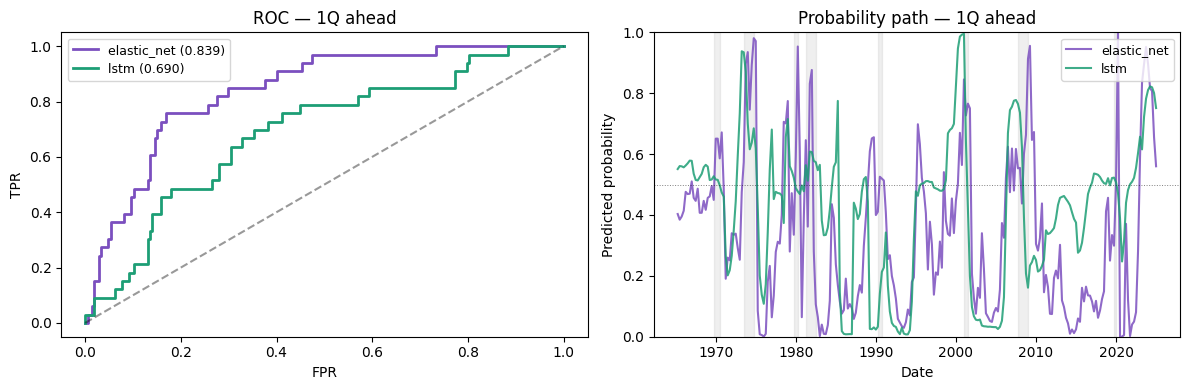

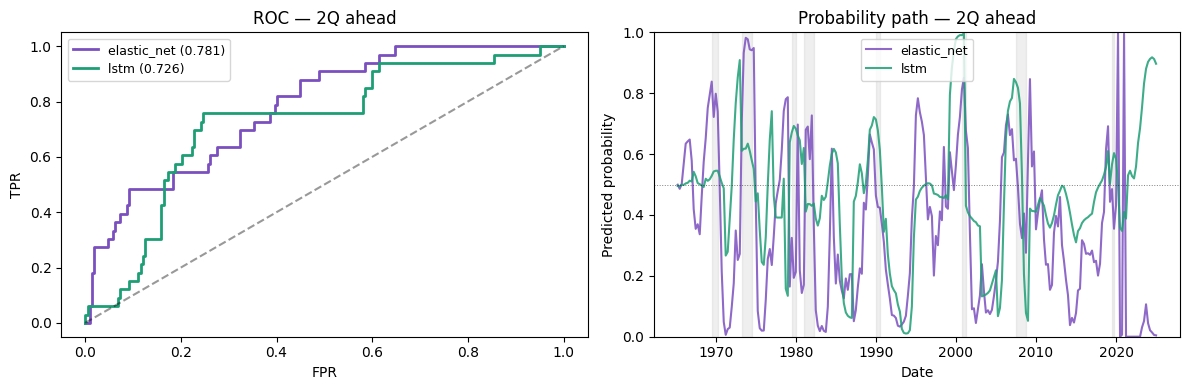

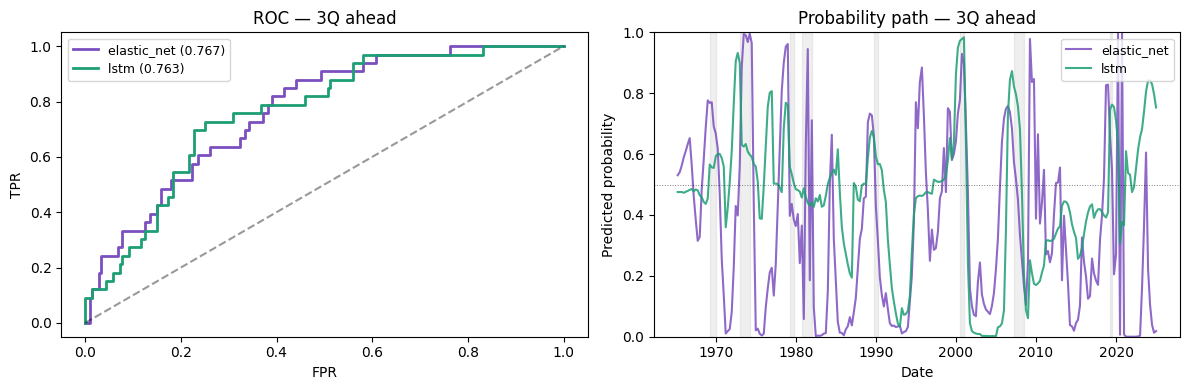

In [44]:
for horizon in horizons:
    if (horizon, "lstm") not in oof_store: continue
    label = horizon.replace("Target_","").replace("_ahead","")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for mname, color in [("elastic_net", "#7B4FBF"), ("lstm", "#1D9E75")]:
        if (horizon, mname) not in oof_store: continue
        frame = oof_store[(horizon, mname)]
        fpr, tpr, _ = roc_curve(frame["y_true"], frame["y_prob"])
        auc_val = roc_auc_score(frame["y_true"], frame["y_prob"])
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{mname} ({auc_val:.3f})")
        axes[1].plot(frame["Date"], frame["y_prob"], color=color, lw=1.5, alpha=0.85, label=mname)
    axes[0].plot([0,1],[0,1],"k--",alpha=0.4); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title(f"ROC — {label} ahead"); axes[0].legend(fontsize=9)
    base_frame = oof_store.get((horizon, "elastic_net"))
    if base_frame is not None:
        axes[1].fill_between(base_frame["Date"],0,1,where=base_frame["y_true"].astype(bool),
                             alpha=0.12,color="grey",transform=axes[1].get_xaxis_transform())
    axes[1].axhline(0.5,color="black",ls=":",lw=0.7,alpha=0.5); axes[1].set_ylim(0,1)
    axes[1].set_xlabel("Date"); axes[1].set_ylabel("Predicted probability")
    axes[1].set_title(f"Probability path — {label} ahead"); axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, f"{horizon}_lstm_vs_baseline.png"), dpi=150); plt.show()

## 10.4 – Go / No-Go Verdict

In [45]:
rnn_df = pd.DataFrame(rnn_results)
print("LSTM vs Elastic Net — per-horizon summary\n" + "="*60)
display(rnn_df.round(4))

if len(rnn_df) == 0:
    print("No LSTM results available — check training logs above.")
else:
    mean_delta       = rnn_df["delta_auc"].mean()
    horizons_beating = (rnn_df["delta_auc"] > 0).sum()
    print(f"\nMean AUC delta (LSTM − elastic_net): {mean_delta:+.4f}")
    print(f"Horizons where LSTM beats baseline:  {horizons_beating} / {len(rnn_df)}")
    print(f"Proceed threshold:                   +{RNN_PROCEED_THRESHOLD:.2f}\n")

    if mean_delta >= RNN_PROCEED_THRESHOLD:
        verdict   = "GO"
        rationale = (
            f"The LSTM improves mean AUC by {mean_delta:+.4f}, exceeding the {RNN_PROCEED_THRESHOLD:.2f} threshold.\n"
            "Temporal structure not captured by engineered features appears to exist.\n\n"
            "Recommended next steps:\n"
            "  1. Expand hyperparameter search (hidden units, layers, seq_len).\n"
            "  2. Trial GRU as a parameter-efficient alternative.\n"
            "  3. Add LSTM as a base model in the stacking ensemble (Section 7).\n"
            "  4. Apply isotonic recalibration before deployment."
        )
    else:
        verdict   = "NO-GO"
        rationale = (
            f"The LSTM improves mean AUC by only {mean_delta:+.4f}, below the {RNN_PROCEED_THRESHOLD:.2f} threshold.\n"
            "The tabular models already capture the relevant temporal structure.\n\n"
            "Likely causes:\n"
            "  - Insufficient training sequences (~150 quarterly observations).\n"
            "  - Lag/rolling features pre-encode most predictable temporal patterns.\n"
            "  - Class imbalance degrades LSTM gradient quality more than tabular models.\n\n"
            "Recommendation: retain elastic_net as the primary model."
        )

    bar = "\u2593" * 62
    print(bar); print(f"  VERDICT: {verdict}"); print(bar); print()
    print(rationale)
    rnn_df["verdict"] = verdict
    rnn_df.to_csv(os.path.join(OUTDIR, "rnn_feasibility_verdict.csv"), index=False)

LSTM vs Elastic Net — per-horizon summary


,horizon,lstm_auc,lstm_ap,baseline_auc,delta_auc
0,1Q,0.6901,0.2667,0.8393,-0.1492
1,2Q,0.7255,0.2895,0.7811,-0.0556
2,3Q,0.7628,0.3570,0.7671,-0.0042



Mean AUC delta (LSTM − elastic_net): -0.0697
Horizons where LSTM beats baseline:  0 / 3
Proceed threshold:                   +0.02

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  VERDICT: NO-GO
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

The LSTM improves mean AUC by only -0.0697, below the 0.02 threshold.
The tabular models already capture the relevant temporal structure.

Likely causes:
  - Insufficient training sequences (~150 quarterly observations).
  - Lag/rolling features pre-encode most predictable temporal patterns.
  - Class imbalance degrades LSTM gradient quality more than tabular models.

Recommendation: retain elastic_net as the primary model.


## 10.5 – Final Metrics Table (All Models)

In [46]:
results_df_final = pd.DataFrame(all_results).sort_values(["horizon","model"]).reset_index(drop=True)
print("Final out-of-sample metrics — all models including LSTM:")
display(results_df_final.round(4))
results_df_final.to_csv(os.path.join(OUTDIR, "xgb_model_comparison_final.csv"), index=False)

Final out-of-sample metrics — all models including LSTM:


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,elastic_net,240,33,0.8393,0.4137,0.1507,0.5948
1,1Q,lstm,240,33,0.6901,0.2667,0.2225,0.6487
2,1Q,smote_xgb,240,33,0.8258,0.4153,0.1186,0.3871
3,1Q,stack_ensemble,48,2,0.9565,0.4500,0.0603,0.2667
4,1Q,xgb_default,240,33,0.8437,0.5183,0.1060,0.3459
5,1Q,xgb_tuned,240,33,0.8535,0.5123,0.1057,0.3363
6,2Q,elastic_net,240,33,0.7811,0.3836,0.1696,0.5786
7,2Q,lstm,240,33,0.7255,0.2895,0.2435,0.7191
8,2Q,smote_xgb,240,33,0.7784,0.3179,0.1412,0.4607
9,2Q,stack_ensemble,48,2,0.9565,0.4167,0.1242,0.4308


---

## Notes for the Report

### Model summary
| Model | Key strength | Watch out for |
|---|---|---|
| `xgb_tuned` | Non-linear threshold effects | Calibration, class imbalance sensitivity |
| `xgb_default` | Fast baseline | No tuning, sub-optimal AP |
| `elastic_net` | Stable with correlated lags (yield curve) | **High AUC but poor log-loss** — rank ordering is good, probabilities need recalibration |
| `smote_xgb` | Richer minority-class decision boundary | Synthetic points may be unrealistic |
| `stack_ensemble` | Combines complementary errors from all base models | Fewer OOF points; **may fall below AUC 0.5 for longer horizons** due to meta-learner overfitting |
| `lstm` | Learns raw temporal dependencies | Needs far more data; often loses to tabular models here |

### Calibration warning
- Elastic net's AUC/log-loss gap indicates the model ranks well but outputs poorly calibrated probabilities. Apply Platt or isotonic recalibration before any probability-threshold-based decision.
- With only 8 recession quarters in 80 OOF observations (10% base rate), all probability estimates should be treated with caution.

### Regime robustness
- Regimes are merged to **pre-GFC / post-GFC** because the walk-forward window starts ~2001 (index 60), leaving zero pre-2000 OOF observations. Splitting into 4 regimes left most bins with < 2 recession quarters.
- `MIN_POSITIVES` is set to 2 (not 5) given the small sample. Flagged reliability is correspondingly lower.

### Stacking ensemble
- The meta-learner uses `initial=30` (expanded from 20) to reduce overfitting on the small OOF pool.
- If AUC < 0.5 for any horizon, the ensemble prediction is unreliable for that horizon and should be excluded from the final recommendation.

### Reporting guidance — RNN section
- **Report the Go/No-Go verdict first.** The binary decision is the deliverable.
- A `NO-GO` is a *positive finding* for the tabular approach — it confirms elastic_net is not leaving temporal signal on the table.
- If `GO`, add the LSTM as an additional base model in Section 7 (stacking ensemble) and re-run.
- The LSTM used here is intentionally minimal. A `NO-GO` does not rule out Temporal Convolutional Networks or Transformer encoders given more data.
- **Always check LSTM calibration** before deployment — sigmoid outputs from BCEWithLogitsLoss are not inherently well-calibrated on imbalanced data.

